# A Reimplementation of Transformer Hawkes Process
### Guidance:
- Step 1: Download the datasets from this [link](https://drive.google.com/drive/folders/0BwqmV0EcoUc8UklIR1BKV25YR1U?resourcekey=0-OrlU87jyc1m-dVMmY5aC4w). Please download the folder `/data_meme`, `/data_mimic`, and `/data_so`.
- Step 2: Unzip the archive and upload to your Google Drive.
- Step 3: Download this as a `.ipynb` on the `File`->`Download`->`Download .ipynb` and save into your Google Drive.
- Step 4: Open Google Colab and click the folder icon on the left bar, and click the folder on the tab with Google Drive icon on it to mount the drive.
- Step 5: Modify the `data_path` on from Cell 10-1 to Cell 11-5 to your dataset's path.
- Step 6: Change your runtime to GPU (not CPU).
- Step 7: Click the `Runtime` on the window's tab and choose `Run all`.
- Step 8: Wait for the traing and testing and Done!

In [1]:
# @title 1 . Setup and Imports
# Install necessary libraries (if not already present in Colab)

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import time
from tqdm.notebook import tqdm
import pickle
import os
import gdown
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [2]:
# @title 2 . Configuration / Hyperparameters



# Model Parameters (Adjust based on StackOverflow in paper/reference code if possible)
d_model = 64       # Model dimension
n_head = 4         # Number of attention heads
d_k = d_model // n_head # Dimension of key/query per head
d_v = d_model // n_head # Dimension of value per head
d_inner = 128      # Dimension of inner layer in feed-forward net
n_layers = 2       # Number of Transformer layers
dropout = 0.1      # Dropout rate

# Point Process Parameters - Will be set from data
num_event_types = None # Set later from pkl['dim_process'] + 1 (for padding)

# Training Parameters
epochs = 30 # Increased epochs might be needed
batch_size = 32
# >>>>> Critical: Adjust Learning Rate and Weights based on experiments <<<<<
learning_rate = 1e-4 # Start potentially lower, especially if loss doesn't decrease
log_likelihood_weight = 1.0
prediction_time_weight = 1.0 # Increased weight for time prediction
prediction_type_weight = 0.1 # Potentially decrease type weight if accuracy is already high

# Small constant for numerical stability (e.g., log(x+eps))
EPS = 1e-8

In [3]:
# @title 3 . Building Blocks: Modules and SubLayers

class ScaleDotProductAttention(nn.Module):
    """ Scaled Dot-Product Attention """
    def __init__(self, temperature, attn_dropout=0.1):
        super().__init__()
        self.temperature = temperature
        self.dropout = nn.Dropout(attn_dropout)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, q, k, v, mask=None):
        attn = torch.matmul(q / self.temperature, k.transpose(-2, -1))
        if mask is not None:
            attn = attn.masked_fill(mask == 0, -1e9)
        attn = self.softmax(attn)
        attn = self.dropout(attn)
        output = torch.matmul(attn, v)
        return output, attn

class MultiHeadAttention(nn.Module):
    """ Multi-Head Attention module """
    def __init__(self, n_head, d_model, d_k, d_v, dropout=0.1):
        super().__init__()
        self.n_head = n_head
        self.d_k = d_k
        self.d_v = d_v

        self.w_qs = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_ks = nn.Linear(d_model, n_head * d_k, bias=False)
        self.w_vs = nn.Linear(d_model, n_head * d_v, bias=False)
        self.fc = nn.Linear(n_head * d_v, d_model, bias=False)

        self.attention = ScaleDotProductAttention(temperature=d_k ** 0.5, attn_dropout=dropout)
        self.dropout = nn.Dropout(dropout)
        self.layer_norm = nn.LayerNorm(d_model, eps=1e-6)

    def forward(self, q, k, v, mask=None):
        d_k, d_v, n_head = self.d_k, self.d_v, self.n_head
        sz_b, len_q, len_k, len_v = q.size(0), q.size(1), k.size(1), v.size(1)
        residual = q

        q = self.w_qs(q).view(sz_b, len_q, n_head, d_k)
        k = self.w_ks(k).view(sz_b, len_k, n_head, d_k)
        v = self.w_vs(v).view(sz_b, len_v, n_head, d_v)

        q, k, v = q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2)

        if mask is not None:
             mask = mask.unsqueeze(1) # For head axis broadcasting.

        q, attn = self.attention(q, k, v, mask=mask)

        q = q.transpose(1, 2).contiguous().view(sz_b, len_q, -1)
        q = self.dropout(self.fc(q))
        q += residual
        q = self.layer_norm(q)
        return q, attn


class PositionwiseFeedForward(nn.Module):
    """ A two-feed-forward-layer module """
    def __init__(self, d_in, d_hid, dropout=0.1):
        super().__init__()
        self.w_1 = nn.Linear(d_in, d_hid) # position-wise
        self.w_2 = nn.Linear(d_hid, d_in) # position-wise
        self.layer_norm = nn.LayerNorm(d_in, eps=1e-6)
        self.dropout = nn.Dropout(dropout)
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        x = self.w_2(self.relu(self.w_1(x)))
        x = self.dropout(x)
        x += residual
        x = self.layer_norm(x)
        return x

In [4]:
# @title 4 . Transformer Encoder Layer

class EncoderLayer(nn.Module):
    """ Compose with two layers """
    def __init__(self, d_model, d_inner, n_head, d_k, d_v, dropout=0.1):
        super().__init__()
        self.slf_attn = MultiHeadAttention(n_head, d_model, d_k, d_v, dropout=dropout)
        self.pos_ffn = PositionwiseFeedForward(d_model, d_inner, dropout=dropout)

    def forward(self, enc_input, slf_attn_mask=None):
        # Note: MultiHeadAttention expects mask==0 for masked positions
        enc_output, enc_slf_attn = self.slf_attn(
            enc_input, enc_input, enc_input, mask=slf_attn_mask)
        enc_output = self.pos_ffn(enc_output)
        return enc_output, enc_slf_attn


In [5]:
# @title 5 . Temporal Encoding

def get_temporal_encoding(times, d_model):
    """
    Generate temporal encoding similar to positional encoding.
    Args:
        times: Tensor of time stamps, shape [batch_size, seq_len]
        d_model: Dimension of the model embeddings.
    Returns:
        Temporal encoding tensor, shape [batch_size, seq_len, d_model]
    """
    batch_size, seq_len = times.size()
    pe = torch.zeros(batch_size, seq_len, d_model, device=times.device)
    position = times.unsqueeze(2)
    div_term = torch.exp(torch.arange(0, d_model, 2, device=times.device).float() * -(math.log(10000.0) / d_model))
    pe[:, :, 0::2] = torch.sin(position * div_term)
    pe[:, :, 1::2] = torch.cos(position * div_term)
    return pe


In [13]:
# @title 6 . THP Model Definition

class THP(nn.Module):
    """ Transformer Hawkes Process Model """
    def __init__(self, num_types, d_model, n_layers, n_head, d_k, d_v, d_inner, dropout):
        super().__init__()

        self.num_types = num_types # K+1 (including padding type 0)
        self.d_model = d_model
        self.n_layers = n_layers
        self.n_head = n_head


        self.event_emb = nn.Embedding(num_types, d_model, padding_idx=0)

        self.layer_stack = nn.ModuleList([
            EncoderLayer(d_model, d_inner, n_head, d_k, d_v, dropout=dropout)
            for _ in range(n_layers)])

        # Parameters for the intensity function
        self.history_weight_layer = nn.Linear(d_model, num_types) # w_k
        self.current_interval_weight = nn.Parameter(torch.Tensor(num_types)) # alpha_k (Not explicitly used in simplified NLL calc)
        self.base_intensity = nn.Parameter(torch.Tensor(num_types)) # b_k
        self.softness_param_raw = nn.Parameter(torch.Tensor(num_types)) # For beta_k

        # --- Predictors (Following paper's structure: Linear without bias/activation) ---
        # Prediction of next log time interval
        self.time_predictor = nn.Linear(d_model, 1, bias=False)

        # Prediction of next event type logits
        self.type_predictor = nn.Linear(d_model, num_types, bias=False)
        # --- End Predictors ---

        self.dropout = nn.Dropout(p=dropout)

        # Initialize parameters
        self._initialize_parameters()


    def _initialize_parameters(self):
        # Initialize intensity parameters
        nn.init.xavier_normal_(self.history_weight_layer.weight)
        if self.history_weight_layer.bias is not None: # Check if bias exists
             nn.init.constant_(self.history_weight_layer.bias, 0.0)
        nn.init.normal_(self.current_interval_weight, mean=0.0, std=0.1)
        nn.init.normal_(self.base_intensity, mean=0.0, std=0.1)
        nn.init.normal_(self.softness_param_raw, mean=0.0, std=0.1)

        # Initialize predictors (as per paper snippet)
        nn.init.xavier_normal_(self.time_predictor.weight)
        nn.init.xavier_normal_(self.type_predictor.weight)


    def get_softness(self):
        return F.softplus(self.softness_param_raw) + EPS # Add EPS for stability

    def get_non_pad_mask(self, seq):
        assert seq.dim() == 2
        return seq.ne(0).unsqueeze(-1) # [batch_size, seq_len, 1]

    def get_attn_key_pad_mask(self, seq_k, seq_q):
        len_q = seq_q.size(1)
        padding_mask = seq_k.eq(0) # 0 is padding index
        padding_mask = padding_mask.unsqueeze(1).expand(-1, len_q, -1) # [batch, len_q, len_k]
        return padding_mask

    def get_subsequent_mask(self, seq):
        sz_b, len_s = seq.size()
        subsequent_mask = torch.triu(
            torch.ones((len_s, len_s), device=seq.device, dtype=torch.uint8), diagonal=1)
        subsequent_mask = subsequent_mask.unsqueeze(0).expand(sz_b, -1, -1) # [sz_b, len_s, len_s]
        return subsequent_mask # 1 means masked

    def forward(self, event_type, event_time):
        """
        Returns:
            enc_output: Hidden states [batch_size, seq_len, d_model]
            all_lambda_k: Intensities per type [batch_size, seq_len, num_types]
            pred_log_intervals: Predicted log time intervals [batch_size, seq_len, 1]
            next_type_logits: Predicted type logits [batch_size, seq_len, num_types]
        """
        non_pad_mask = self.get_non_pad_mask(event_type) # 1 where not padded
        slf_attn_mask_keypad = self.get_attn_key_pad_mask(seq_k=event_type, seq_q=event_type) # 1 where key is padded
        slf_attn_mask_subseq = self.get_subsequent_mask(event_type) # 1 where subsequent
        # Combine masks: mask if key is padding OR if subsequent
        # For PyTorch attention: mask should be True where attention is NOT allowed
        slf_attn_mask = (slf_attn_mask_keypad | slf_attn_mask_subseq).bool() # True means masked

        type_emb = self.event_emb(event_type)
        temp_enc = get_temporal_encoding(event_time, self.d_model)
        enc_input = type_emb + temp_enc
        enc_input = self.dropout(enc_input) * non_pad_mask # Apply mask early?

        enc_output = enc_input
        for enc_layer in self.layer_stack:
            # Pass the combined mask, True where masked
            enc_output, _ = enc_layer(enc_output, slf_attn_mask=slf_attn_mask)
            enc_output *= non_pad_mask # Zero out padding positions after each layer


        # --- Intensity Calculation ---
        h = enc_output # Hidden states [batch, seq_len, d_model]
        history_influence = self.history_weight_layer(h) # [batch, seq_len, num_types]
        base_term = self.base_intensity.unsqueeze(0).unsqueeze(0) # [1, 1, num_types]
        softness = self.get_softness().unsqueeze(0).unsqueeze(0) # [1, 1, num_types]

        intensity_argument = history_influence + base_term
        beta_inv = 1.0 / softness # Use 1/beta for F.softplus to match paper's formula style
        all_lambda_k = torch.nn.functional.softplus(intensity_argument)
        all_lambda_k = all_lambda_k / beta_inv * softness  # [batch, seq_len, num_types]


        # --- Predictions ---
        # Type predictor outputs logits
        next_type_logits = self.type_predictor(h) # [batch, seq_len, num_types]
        # Time predictor outputs log interval directly (no activation)
        pred_log_intervals = self.time_predictor(h) # [batch, seq_len, 1]

        # Mask predictor outputs at padding positions (optional, loss function handles it)
        # next_type_logits *= non_pad_mask
        # pred_log_intervals *= non_pad_mask

        return enc_output, all_lambda_k, pred_log_intervals, next_type_logits


In [7]:
# @title 7 . Loss Function Definition

def compute_log_likelihood(all_lambda_k_at_event, seq_times, seq_types, non_pad_mask):
    """
    Compute the log-likelihood loss (NLL).
    Args:
        all_lambda_k_at_event: Intensity per type lambda_k(t_j|H_j), shape [batch_size, seq_len, num_types]
        seq_times: Event times, shape [batch_size, seq_len]
        seq_types: Event types, shape [batch_size, seq_len]
        non_pad_mask: Mask for non-padding elements, shape [batch_size, seq_len, 1]
    Returns:
        Negative Log-likelihood loss per valid event.
    """
    batch_size, seq_len, num_types = all_lambda_k_at_event.shape

    # 1. Event log-likelihood: sum_{j=1}^L log lambda_{k_j}(t_j | H_j)
    lambda_k_at_event = torch.gather(all_lambda_k_at_event, dim=2, index=seq_types.unsqueeze(2)).squeeze(2)
    log_lambda = torch.log(lambda_k_at_event + EPS)
    log_lambda_masked = log_lambda * non_pad_mask.squeeze(-1)
    event_ll_sum = log_lambda_masked.sum(dim=1) # [batch_size]

    # 2. Non-event log-likelihood: - integral_{t_1}^{t_L} lambda(t | Ht) dt
    lambda_sum_at_event = all_lambda_k_at_event.sum(dim=2) # lambda(t_j|H_j) = sum_k lambda_k(t_j|H_j)
    delta_t = seq_times[:, 1:] - seq_times[:, :-1]
    delta_t = F.pad(delta_t, (1, 0), "constant", 0) # [batch_size, seq_len], delta_t_j = t_j - t_{j-1}

    # Trapezoidal rule: Integral(j-1 to j) approx (lambda(t_{j-1}) + lambda(t_j)) * delta_t_j / 2
    # Shift lambda_sum to get lambda(t_{j-1}) aligned with delta_t_j
    lambda_sum_start = torch.roll(lambda_sum_at_event, shifts=1, dims=1)
    lambda_sum_start[:, 0] = 0 # Assume lambda(t_0) = 0
    lambda_sum_end = lambda_sum_at_event

    integral_approx_interval = (lambda_sum_start + lambda_sum_end) * delta_t / 2.0
    integral_approx_masked = integral_approx_interval * non_pad_mask.squeeze(-1)
    non_event_ll_integral_sum = integral_approx_masked.sum(dim=1) # [batch_size]

    # Total log-likelihood per sequence
    log_likelihood_seq = event_ll_sum - non_event_ll_integral_sum

    # --- Normalize by number of valid EVENTS ---
    # Loss should be per event for comparability
    num_events_per_seq = non_pad_mask.squeeze(-1).sum(dim=1).float() # [batch_size]
    # Avoid division by zero for sequences with no events (if any)
    num_events_per_seq = torch.max(num_events_per_seq, torch.ones_like(num_events_per_seq))

    # Average NLL per event for each sequence, then average over batch
    nll_loss_per_seq = -log_likelihood_seq / num_events_per_seq
    nll_loss = nll_loss_per_seq.mean()


    return nll_loss

In [8]:
# @title 8 . Data Loading and Dataset Definition (Using .pkl files)
def compute_pred_loss(pred_log_intervals, next_type_logits, event_time, event_type, non_pad_mask):
    """
    Compute prediction losses for time (log interval MSE) and type (CrossEntropy).
    Normalization is done per valid PREDICTION.
    Args:
        pred_log_intervals: Predicted log time intervals, shape [batch_size, seq_len, 1]
        next_type_logits: Predicted type logits, shape [batch_size, seq_len, num_types]
        event_time: Ground truth event times, shape [batch_size, seq_len]
        event_type: Ground truth event types, shape [batch_size, seq_len]
        non_pad_mask: Mask for non-padding elements, shape [batch_size, seq_len, 1]
    Returns:
        time_loss (MSE on log intervals, avg per valid pred),
        type_loss (CrossEntropy, avg per valid pred)
    """
    # --- Time Prediction Loss (MSE on Log Intervals) ---
    true_time_intervals = event_time[:, 1:] - event_time[:, :-1]
    # Clamp true intervals before log to avoid log(0) or log(neg)
    true_time_intervals = torch.clamp(true_time_intervals, min=EPS)
    true_log_intervals = torch.log(true_time_intervals)
    # Pad at the end to match seq_len (target for prediction at step j is interval j -> j+1)
    true_log_intervals = F.pad(true_log_intervals, (0, 1), "constant", 0) # Pad value doesn't matter due to mask

    time_pred_log = pred_log_intervals.squeeze(-1) # [batch_size, seq_len]

    # Calculate MSE loss (comparing log values)
    time_loss_unmasked = F.mse_loss(time_pred_log, true_log_intervals, reduction='none') # [batch_size, seq_len]

    # --- Type Prediction Loss (Cross Entropy) ---
    true_next_types = torch.roll(event_type, shifts=-1, dims=1) # True type at j+1
    true_next_types[:, -1] = 0 # Set last target to padding index

    type_pred_logits_flat = next_type_logits.view(-1, next_type_logits.size(-1))
    true_next_types_flat = true_next_types.view(-1)
    type_loss_unmasked = F.cross_entropy(type_pred_logits_flat, true_next_types_flat, ignore_index=0, reduction='none')
    type_loss_unmasked = type_loss_unmasked.view(event_type.size(0), -1) # [batch_size, seq_len]

    # --- Masking and Normalization by VALID PREDICTIONS ---
    # A prediction at step j is valid if event j is not padding AND event j+1 exists and is not padding.
    valid_pred_mask = non_pad_mask.squeeze(-1).bool() & (true_next_types != 0) # [batch_size, seq_len]
    num_valid_preds = valid_pred_mask.sum()

    # Apply mask and sum losses
    time_loss_sum = (time_loss_unmasked * valid_pred_mask).sum()
    type_loss_sum = (type_loss_unmasked * valid_pred_mask).sum()

    # Normalize by number of valid predictions
    if num_valid_preds > 0:
        time_loss_avg = time_loss_sum / num_valid_preds
        type_loss_avg = type_loss_sum / num_valid_preds
    else:
        time_loss_avg = torch.tensor(0.0, device=event_time.device)
        type_loss_avg = torch.tensor(0.0, device=event_time.device)

    return time_loss_avg, type_loss_avg




def load_pkl_data(filepath):
    """Loads data from a pickle file."""
    if not os.path.exists(filepath):
        raise FileNotFoundError(f"Data file not found: {filepath}. Please upload or adjust path.")
    try:
        with open(filepath, 'rb') as f:
            data = pickle.load(f, encoding="latin-1")
        print(f"Successfully loaded data from: {filepath}")
        # Print some basic info
        print(f"  Keys: {list(data.keys())}")
        if 'dim_process' in data:
             print(f"  Dimension (K): {data['dim_process']}")
        for split in ['train', 'dev', 'test']:
             if split in data and isinstance(data[split], list):
                 print(f"  Number of sequences in '{split}': {len(data[split])}")
        return data
    except Exception as e:
        print(f"Error loading data from {filepath}: {e}")
        raise


class EventSequenceDatasetPkl(Dataset):
    """PyTorch Dataset for event sequences loaded from .pkl."""
    def __init__(self, sequences, time_unit_scaler=1.0):
        """
        Args:
            sequences: List of sequences (list of event dicts).
            time_unit_scaler: Factor to scale time values (e.g., 1/(24*60*60) if converting seconds to days). Default is 1.0 (no scaling).
        """
        self.sequences = sequences
        self.time_unit_scaler = time_unit_scaler
        print(f"Dataset initialized with {len(sequences)} sequences. Time scaler: {time_unit_scaler}")

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        sequence = self.sequences[idx]
        if not sequence: # Handle potentially empty sequences in pkl
            #print(f"Warning: Empty sequence found at index {idx}")
            return torch.tensor([], dtype=torch.float32), torch.tensor([], dtype=torch.long)

        # Assuming 'time_since_start' is the absolute time in the desired unit (or applying scaler)
        # Perform scaling here if needed
        times = [event['time_since_start'] * self.time_unit_scaler for event in sequence]
        # Convert type_event (might be numpy int) to standard int for tensor creation
        types = [int(event['type_event']) for event in sequence]

        times_tensor = torch.tensor(times, dtype=torch.float32)
        types_tensor = torch.tensor(types, dtype=torch.long) # Ensure LongTensor for embedding index

        return times_tensor, types_tensor

def collate_fn(batch):
    """Collate function to pad sequences in a batch."""
    # Filter out None items if dataset returns None for invalid indices
    batch = [item for item in batch if item is not None]
    if not batch:
        return None # Return None if batch is empty after filtering

    times, types = zip(*batch)

    # Filter out completely empty sequences returned by dataset's __getitem__
    non_empty_indices = [i for i, t in enumerate(times) if len(t) > 0]
    if not non_empty_indices:
         return None # Return None if all sequences in the batch were empty

    times_filtered = [times[i] for i in non_empty_indices]
    types_filtered = [types[i] for i in non_empty_indices]

    # Pad sequences
    padded_times = nn.utils.rnn.pad_sequence(times_filtered, batch_first=True, padding_value=0.0)
    padded_types = nn.utils.rnn.pad_sequence(types_filtered, batch_first=True, padding_value=0) # Use 0 for padding type

    return padded_times.to(device), padded_types.to(device)

In [9]:
# @title 9 . Train, Validate, and Test All in one
def get_result(data_path):
  TRAIN_PKL_PATH = data_path+'train.pkl'
  DEV_PKL_PATH = data_path+'dev.pkl'
  TEST_PKL_PATH = data_path+'test.pkl'

  # --- Load the Data ---
  print("Loading data from .pkl files...")
  try:
      train_data_dict = load_pkl_data(TRAIN_PKL_PATH)
      dev_data_dict = load_pkl_data(DEV_PKL_PATH)
      test_data_dict = load_pkl_data(TEST_PKL_PATH)

      # --- Extract Data and Parameters ---
      dim_process = train_data_dict['dim_process']
      num_event_types = int(dim_process) + 1 # Add 1 for padding index 0
      print(f"\nNumber of event types (K): {dim_process}")
      print(f"Model 'num_event_types' (K+1 for padding): {num_event_types}")

      train_sequences = train_data_dict['train']
      dev_sequences = dev_data_dict['dev']
      test_sequences = test_data_dict.get('test', test_data_dict.get('devtest')) # Handle 'test' or 'devtest' key

      if not test_sequences:
          print("Warning: 'test' or 'devtest' key not found in test pkl. Using 'dev' sequences for testing.")
          test_sequences = dev_sequences # Fallback to dev if test is missing

      print(f"Actual number of training sequences loaded: {len(train_sequences)}")
      print(f"Actual number of development sequences loaded: {len(dev_sequences)}")
      print(f"Actual number of test sequences loaded: {len(test_sequences)}")

      # --- Optional: Time Unit Conversion ---
      # If you determined units are seconds and need days, set scaler:
      # time_scaler = 1.0 / (24.0 * 60.0 * 60.0)
      # If units are already days (as suspected for StackOverflow), keep scaler = 1.0
      time_scaler = 1.0
      print(f"Using time scaler: {time_scaler} (1.0 means no change)")

      # --- Create Datasets and DataLoaders ---
      train_dataset = EventSequenceDatasetPkl(train_sequences, time_unit_scaler=time_scaler)
      dev_dataset = EventSequenceDatasetPkl(dev_sequences, time_unit_scaler=time_scaler)
      test_dataset = EventSequenceDatasetPkl(test_sequences, time_unit_scaler=time_scaler)

      train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
      dev_loader = DataLoader(dev_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
      test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

      # --- Optional: Plot Time Interval Distribution ---
      print("\nAnalyzing training time intervals...")
      all_intervals = []
      for seq in train_sequences:
          times = [event['time_since_start'] * time_scaler for event in seq]
          if len(times) > 1:
              intervals = np.diff(times)
              # Filter out potential negative intervals due to data errors
              intervals = intervals[intervals >= 0]
              all_intervals.extend(intervals)

      if all_intervals:
          all_intervals = np.array(all_intervals)
          plt.figure(figsize=(12, 4))
          plt.subplot(1, 2, 1)
          plt.hist(all_intervals, bins=50, range=(0, np.percentile(all_intervals, 99))) # Limit range for better visualization
          plt.title(f'Training Time Intervals (Scaled, Unit={1/time_scaler if time_scaler!=1 else "Original"})')
          plt.xlabel('Interval')
          plt.ylabel('Frequency')

          # Plot log intervals
          plt.subplot(1, 2, 2)
          # Add EPS before log
          log_intervals = np.log(all_intervals + EPS)
          plt.hist(log_intervals, bins=50)
          plt.title('Log Training Time Intervals (Scaled)')
          plt.xlabel('Log(Interval)')
          plt.ylabel('Frequency')
          plt.tight_layout()
          plt.show()
          print(f"Interval Stats (Scaled): Mean={np.mean(all_intervals):.2f}, Median={np.median(all_intervals):.2f}, Max={np.max(all_intervals):.2f}, Min={np.min(all_intervals):.2f}, 99th Percentile={np.percentile(all_intervals, 99):.2f}")
      else:
          print("No valid intervals found to plot.")


  except FileNotFoundError:
      print("*"*50)
      print("ERROR: Data file(s) not found. Please upload train.pkl, dev.pkl, and test.pkl or adjust paths.")
      print("*"*50)
      raise
  except KeyError as e:
      print(f"Error: Missing key {e} in the loaded pkl file. Check file structure.")
      raise
  except Exception as e:
      print(f"An unexpected error occurred during data loading: {e}")
      raise


  # Training Loop

  # --- Instantiate Model ---
  model = THP(
      num_types=num_event_types,
      d_model=d_model,
      n_layers=n_layers,
      n_head=n_head,
      d_k=d_k,
      d_v=d_v,
      d_inner=d_inner,
      dropout=dropout
  ).to(device)

  # Optimizer
  optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.98), eps=1e-9)
  # Optional: Learning Rate Scheduler (Example: simple decay)
  # scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5) # Decay LR by half every 10 epochs

  print(f"\nModel created with {sum(p.numel() for p in model.parameters() if p.requires_grad)} trainable parameters.")
  print("Starting training...")

  train_losses = {'total': [], 'nll': [], 'time': [], 'type': []} # Store losses per epoch

  for epoch in range(epochs):
      model.train()
      epoch_total_loss = 0.0
      epoch_nll_loss = 0.0
      epoch_time_loss = 0.0
      epoch_type_loss = 0.0
      batches_processed = 0
      start_time = time.time()

      progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

      for batch in progress_bar:
          if batch is None: continue # Skip empty batches from collate_fn
          batches_processed += 1
          event_time, event_type = batch

          optimizer.zero_grad()

          # Forward pass - Model now outputs pred_log_intervals
          enc_output, all_lambda_k, pred_log_intervals, next_type_logits = model(event_type, event_time)

          # Calculate losses using the updated functions
          non_pad_mask = model.get_non_pad_mask(event_type)

          # NLL Loss (per event)
          nll_loss = compute_log_likelihood(all_lambda_k, event_time, event_type, non_pad_mask)

          # Prediction Losses (per valid prediction)
          time_loss, type_loss = compute_pred_loss(pred_log_intervals, next_type_logits, event_time, event_type, non_pad_mask)

          # Combined loss
          loss = (log_likelihood_weight * nll_loss +
                  prediction_time_weight * time_loss +
                  prediction_type_weight * type_loss)

          # Backpropagation
          if not torch.isnan(loss) and not torch.isinf(loss):
              loss.backward()
              # Optional: Gradient Clipping
              # torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
              optimizer.step()

              epoch_total_loss += loss.item()
              epoch_nll_loss += nll_loss.item()
              epoch_time_loss += time_loss.item() # This is MSE of log intervals
              epoch_type_loss += type_loss.item()
          else:
              print(f"\nWarning: NaN/Inf loss detected at epoch {epoch+1}, batch {batches_processed}. Skipping update.")
              print(f"NLL: {nll_loss.item()}, Time: {time_loss.item()}, Type: {type_loss.item()}")


          progress_bar.set_postfix({
              'Loss': f"{loss.item():.4f}",
              'NLL': f"{nll_loss.item():.4f}",
              'Time(logMSE)': f"{time_loss.item():.4f}", # Label it correctly
              'Type(CE)': f"{type_loss.item():.4f}"
          })

      # End of epoch
      # if scheduler: scheduler.step() # Update learning rate if using scheduler

      if batches_processed > 0:
          avg_loss = epoch_total_loss / batches_processed
          avg_nll = epoch_nll_loss / batches_processed
          avg_time_log_mse = epoch_time_loss / batches_processed
          avg_type_ce = epoch_type_loss / batches_processed

          train_losses['total'].append(avg_loss)
          train_losses['nll'].append(avg_nll)
          train_losses['time'].append(avg_time_log_mse)
          train_losses['type'].append(avg_type_ce)

          epoch_time = time.time() - start_time
          print(f"Epoch {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | "
                f"Avg Loss: {avg_loss:.4f} | Avg NLL: {avg_nll:.4f} | "
                f"Avg Time(logMSE): {avg_time_log_mse:.4f} | Avg Type(CE): {avg_type_ce:.4f}")
      else:
          print(f"Epoch {epoch+1}/{epochs} | No batches processed.")


  print("Training finished.")

  # Development Evaluation

  model.eval()
  eval_nll_sum = 0.0
  eval_time_sse = 0.0 # Sum of Squared Errors for time (original scale)
  eval_type_loss_sum = 0.0
  total_events_eval = 0
  correct_type_preds_eval = 0
  total_valid_preds_eval = 0 # Number of non-padding predictions made

  # --- Choose DataLoader for Evaluation ---
  eval_loader = dev_loader # Or use test_loader
  eval_set_name = "Development" # Or "Test"
  print(f"\n--- Starting Evaluation on {eval_set_name} Set ---")

  with torch.no_grad():
      eval_progress_bar = tqdm(eval_loader, desc=f"Evaluating {eval_set_name}", leave=False)
      for batch in eval_progress_bar:
          if batch is None: continue
          event_time, event_type = batch
          non_pad_mask = model.get_non_pad_mask(event_type)
          num_events_in_batch = non_pad_mask.sum().item()
          total_events_eval += num_events_in_batch

          if num_events_in_batch == 0: continue

          # Forward pass - Model outputs pred_log_intervals
          enc_output, all_lambda_k, pred_log_intervals, next_type_logits = model(event_type, event_time)

          # --- NLL ---
          nll_loss = compute_log_likelihood(all_lambda_k, event_time, event_type, non_pad_mask)
          eval_nll_sum += nll_loss.item() * num_events_in_batch # Accumulate total NLL

          # --- Prediction Evaluation (Time RMSE and Type Accuracy) ---
          if event_time.shape[1] > 1: # Only if sequences are long enough to predict
              # Get valid prediction mask
              true_next_types_eval = torch.roll(event_type, shifts=-1, dims=1)
              valid_pred_mask_eval = non_pad_mask.squeeze(-1).bool() & (true_next_types_eval != 0)
              num_valid_preds_in_batch = valid_pred_mask_eval.sum().item()

              if num_valid_preds_in_batch > 0:
                  total_valid_preds_eval += num_valid_preds_in_batch

                  # --- Time RMSE ---
                  pred_log_intervals_val = pred_log_intervals.squeeze(-1) #[batch, seq_len]
                  # Convert predicted log intervals back to original time scale
                  pred_time_intervals_val = torch.exp(pred_log_intervals_val)

                  # Calculate true time intervals
                  true_time_intervals_val = event_time[:, 1:] - event_time[:, :-1]
                  true_time_intervals_val = F.pad(true_time_intervals_val, (0, 1), "constant", 0)

                  # Calculate Squared Error on original scale
                  squared_error = F.mse_loss(pred_time_intervals_val, true_time_intervals_val, reduction='none')
                  # Accumulate SSE only for valid predictions
                  eval_time_sse += (squared_error * valid_pred_mask_eval).sum().item()

                  # --- Type Accuracy ---
                  type_loss_ce = F.cross_entropy(next_type_logits.view(-1, num_event_types),
                                                  true_next_types_eval.view(-1),
                                                  ignore_index=0, reduction='none')
                  type_loss_ce = type_loss_ce.view(event_type.size(0), -1)
                  eval_type_loss_sum += (type_loss_ce * valid_pred_mask_eval).sum().item()

                  pred_types_val = next_type_logits.argmax(dim=-1)
                  correct_preds = (pred_types_val == true_next_types_eval) & valid_pred_mask_eval
                  correct_type_preds_eval += correct_preds.sum().item()


  # --- Calculate final metrics ---
  if total_events_eval > 0:
      avg_eval_nll = eval_nll_sum / total_events_eval
  else:
      avg_eval_nll = float('nan')

  if total_valid_preds_eval > 0:
      avg_eval_time_rmse = math.sqrt(eval_time_sse / total_valid_preds_eval)
      avg_eval_type_acc = (correct_type_preds_eval / total_valid_preds_eval) * 100
      avg_eval_type_loss = eval_type_loss_sum / total_valid_preds_eval # Average CE loss
  else:
      avg_eval_time_rmse = float('nan')
      avg_eval_type_acc = float('nan')
      avg_eval_type_loss = float('nan')

  print(f"\n--- Evaluation Results ({eval_set_name} Set) ---")
  print(f"Total Valid Events: {total_events_eval}")
  print(f"Total Valid Predictions: {total_valid_preds_eval}")
  if total_events_eval > 0: print(f"Average NLL per event: {avg_eval_nll:.4f}")
  if total_valid_preds_eval > 0:
      print(f"Time Prediction RMSE: {avg_eval_time_rmse:.4f}") # This is the key metric
      print(f"Type Prediction Accuracy: {avg_eval_type_acc:.2f}%")
      print(f"Type Prediction CrossEntropy: {avg_eval_type_loss:.4f}")

  # Test Evaluation

  eval_nll_sum = 0.0
  eval_time_sse = 0.0 # Sum of Squared Errors for time (original scale)
  eval_type_loss_sum = 0.0
  total_events_eval = 0
  correct_type_preds_eval = 0
  total_valid_preds_eval = 0 # Number of non-padding predictions made

  # --- Choose DataLoader for Evaluation ---
  eval_loader = test_loader # Or use test_loader
  eval_set_name = "Test" # Or "Test"
  print(f"\n--- Starting Evaluation on {eval_set_name} Set ---")

  with torch.no_grad():
      eval_progress_bar = tqdm(eval_loader, desc=f"Evaluating {eval_set_name}", leave=False)
      for batch in eval_progress_bar:
          if batch is None: continue
          event_time, event_type = batch
          non_pad_mask = model.get_non_pad_mask(event_type)
          num_events_in_batch = non_pad_mask.sum().item()
          total_events_eval += num_events_in_batch

          if num_events_in_batch == 0: continue

          # Forward pass - Model outputs pred_log_intervals
          enc_output, all_lambda_k, pred_log_intervals, next_type_logits = model(event_type, event_time)

          # --- NLL ---
          nll_loss = compute_log_likelihood(all_lambda_k, event_time, event_type, non_pad_mask)
          eval_nll_sum += nll_loss.item() * num_events_in_batch # Accumulate total NLL

          # --- Prediction Evaluation (Time RMSE and Type Accuracy) ---
          if event_time.shape[1] > 1: # Only if sequences are long enough to predict
              # Get valid prediction mask
              true_next_types_eval = torch.roll(event_type, shifts=-1, dims=1)
              valid_pred_mask_eval = non_pad_mask.squeeze(-1).bool() & (true_next_types_eval != 0)
              num_valid_preds_in_batch = valid_pred_mask_eval.sum().item()

              if num_valid_preds_in_batch > 0:
                  total_valid_preds_eval += num_valid_preds_in_batch

                  # --- Time RMSE ---
                  pred_log_intervals_val = pred_log_intervals.squeeze(-1) #[batch, seq_len]
                  # Convert predicted log intervals back to original time scale
                  pred_time_intervals_val = torch.exp(pred_log_intervals_val)

                  # Calculate true time intervals
                  true_time_intervals_val = event_time[:, 1:] - event_time[:, :-1]
                  true_time_intervals_val = F.pad(true_time_intervals_val, (0, 1), "constant", 0)

                  # Calculate Squared Error on original scale
                  squared_error = F.mse_loss(pred_time_intervals_val, true_time_intervals_val, reduction='none')
                  # Accumulate SSE only for valid predictions
                  eval_time_sse += (squared_error * valid_pred_mask_eval).sum().item()

                  # --- Type Accuracy ---
                  type_loss_ce = F.cross_entropy(next_type_logits.view(-1, num_event_types),
                                                  true_next_types_eval.view(-1),
                                                  ignore_index=0, reduction='none')
                  type_loss_ce = type_loss_ce.view(event_type.size(0), -1)
                  eval_type_loss_sum += (type_loss_ce * valid_pred_mask_eval).sum().item()

                  pred_types_val = next_type_logits.argmax(dim=-1)
                  correct_preds = (pred_types_val == true_next_types_eval) & valid_pred_mask_eval
                  correct_type_preds_eval += correct_preds.sum().item()

  ##########
  # --- Configuration for Visualization ---
  layer_indices_to_plot = [0, model.n_layers - 1] # Plot first and last layer
  num_heads_to_plot = min(4, model.n_head)      # Plot up to 4 heads
  sequence_index_in_batch = 0                   # Visualize the first sequence in the batch
  # --- End Configuration ---


  # Get a sample batch (use test_loader for generalization visualization)
  try:
      vis_loader = test_loader # Or dev_loader
      vis_batch = next(iter(vis_loader))
      if vis_batch is None and len(vis_loader) > 1: # Handle potential empty first batch
          vis_batch = next(iter(vis_loader))
  except StopIteration:
      print("DataLoader is empty. Cannot get batch for visualization.")
      vis_batch = None
  except NameError:
      print("Make sure test_loader (or dev_loader) exists and data is loaded.")
      vis_batch = None


  if vis_batch:
      event_time_vis, event_type_vis = vis_batch
      event_time_vis = event_time_vis.to(device)
      event_type_vis = event_type_vis.to(device)

      # Ensure the selected sequence index is valid
      if sequence_index_in_batch >= event_time_vis.shape[0]:
          print(f"Warning: sequence_index_in_batch ({sequence_index_in_batch}) is out of bounds for batch size ({event_time_vis.shape[0]}). Visualizing sequence 0 instead.")
          sequence_index_in_batch = 0

      # --- Run forward pass to get attention weights ---
      model.eval() # Set model to evaluation mode
      with torch.no_grad():
          # Call forward with return_attns=True
          outputs = model(event_type_vis, event_time_vis, return_attns=True)
          # Unpack outputs (depends on the number of return values when return_attns=True)
          enc_output, all_lambda_k, pred_log_intervals, next_type_logits, all_attns = outputs
          # all_attns is a list of tensors, one per layer
          # each tensor shape: [batch_size, n_head, seq_len, seq_len]

      # --- Select data for the chosen sequence ---
      # Get the actual length of the sequence before padding
      actual_seq_len = (event_type_vis[sequence_index_in_batch] != 0).sum().item()
      if actual_seq_len == 0:
          print(f"Selected sequence {sequence_index_in_batch} is empty or only padding.")
      else:
          print(f"Visualizing attention for sequence {sequence_index_in_batch} (actual length: {actual_seq_len})")

          # --- Plotting ---
          num_layers_to_plot = len(layer_indices_to_plot)
          fig, axes = plt.subplots(num_layers_to_plot, num_heads_to_plot,
                                  figsize=(num_heads_to_plot * 3, num_layers_to_plot * 3))
          # Adjust layout if only one layer/head
          if num_layers_to_plot == 1 and num_heads_to_plot == 1:
              axes = np.array([[axes]])
          elif num_layers_to_plot == 1:
              axes = axes.reshape(1, -1)
          elif num_heads_to_plot == 1:
              axes = axes.reshape(-1, 1)


          for row, layer_idx in enumerate(layer_indices_to_plot):
              if layer_idx >= len(all_attns):
                  print(f"Warning: Layer index {layer_idx} out of bounds for available attention weights ({len(all_attns)} layers). Skipping.")
                  continue

              # Get attention for the specific layer and sequence
              # Shape: [n_head, seq_len, seq_len]
              attn_layer = all_attns[layer_idx][sequence_index_in_batch].cpu().numpy()

              for col in range(num_heads_to_plot):
                  ax = axes[row, col]
                  # Get attention for the specific head
                  # Shape: [seq_len, seq_len]
                  attn_head = attn_layer[col]

                  # Crop to actual sequence length for better visualization
                  attn_cropped = attn_head[:actual_seq_len, :actual_seq_len]
                  attn_transposed = attn_cropped.T
                  # Plot heatmap
                  im = ax.imshow(attn_transposed, cmap='hot', interpolation='nearest', aspect='auto', origin='upper') # 'hot' or 'viridis' or 'magma'
                  ax.set_title(f'Layer {layer_idx + 1}, Head {col + 1}')
                  ax.set_xlabel('Key Event Position (j)')
                  ax.set_ylabel('Query Event Position (i)')
                  # Optional: Add colorbar
                  # fig.colorbar(im, ax=ax)

                  # Hide upper triangle (optional, as causal mask should make it zero anyway)
                  # mask_vis = np.triu(np.ones_like(attn_cropped), k=1)
                  # ax.imshow(np.ma.masked_where(mask_vis, attn_cropped), cmap='hot')


          plt.suptitle(f'Attention Patterns for Sequence {sequence_index_in_batch}')
          plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
          plt.show()

  else:
      print("Could not obtain a batch for visualization.")
  ##############################



  # --- Calculate final metrics ---
  if total_events_eval > 0:
      avg_eval_nll = eval_nll_sum / total_events_eval
  else:
      avg_eval_nll = float('nan')

  if total_valid_preds_eval > 0:
      avg_eval_time_rmse = math.sqrt(eval_time_sse / total_valid_preds_eval)
      avg_eval_type_acc = (correct_type_preds_eval / total_valid_preds_eval) * 100
      avg_eval_type_loss = eval_type_loss_sum / total_valid_preds_eval # Average CE loss
  else:
      avg_eval_time_rmse = float('nan')
      avg_eval_type_acc = float('nan')
      avg_eval_type_loss = float('nan')

  print(f"\n--- Evaluation Results ({eval_set_name} Set) ---")
  print(f"Total Valid Events: {total_events_eval}")
  print(f"Total Valid Predictions: {total_valid_preds_eval}")
  if total_events_eval > 0: print(f"Average NLL per event: {avg_eval_nll:.4f}")
  if total_valid_preds_eval > 0:
    print(f"Time Prediction RMSE: {avg_eval_time_rmse:.4f}") # This is the key metric
    print(f"Type Prediction Accuracy: {avg_eval_type_acc:.2f}%")
    print(f"Type Prediction CrossEntropy: {avg_eval_type_loss:.4f}")


  # Plot Training Losses

  plt.figure(figsize=(12, 8))

  plt.subplot(2, 2, 1)
  plt.plot(train_losses['total'])
  plt.title('Average Total Loss per Epoch')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')

  plt.subplot(2, 2, 2)
  plt.plot(train_losses['nll'])
  plt.title('Average NLL Loss per Epoch')
  plt.xlabel('Epoch')
  plt.ylabel('NLL')

  plt.subplot(2, 2, 3)
  plt.plot(train_losses['time'])
  plt.title('Average Time Loss (logMSE) per Epoch')
  plt.xlabel('Epoch')
  plt.ylabel('Log MSE')

  plt.subplot(2, 2, 4)
  plt.plot(train_losses['type'])
  plt.title('Average Type Loss (CE) per Epoch')
  plt.xlabel('Epoch')
  plt.ylabel('CrossEntropy')

  plt.tight_layout()
  plt.show()

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold1/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 4777
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold1/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 530
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold1/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 1326

Number of event types (K): 22
Model 'num_event_types' (K+1 for padding): 23
Actual number

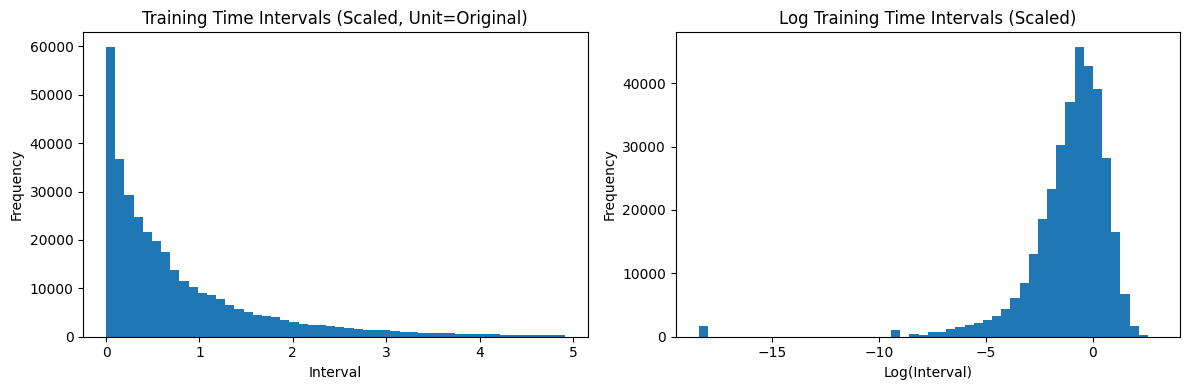

Interval Stats (Scaled): Mean=0.83, Median=0.48, Max=20.34, Min=0.00, 99th Percentile=4.91

Model created with 71004 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/30 | Time: 2.33s | Avg Loss: 10.8282 | Avg NLL: 6.1389 | Avg Time(logMSE): 4.3049 | Avg Type(CE): 3.8439


Epoch 2/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/30 | Time: 2.35s | Avg Loss: 6.8660 | Avg NLL: 2.8663 | Avg Time(logMSE): 3.7458 | Avg Type(CE): 2.5398


...

Epoch 30/30 | Time: 2.33s | Avg Loss: 3.7208 | Avg NLL: 0.9749 | Avg Time(logMSE): 2.6013 | Avg Type(CE): 1.4462
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/17 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 35730
Total Valid Predictions: 33121
Average NLL per event: 0.9480
Time Prediction RMSE: 1.0452
Type Prediction Accuracy: 52.87%
Type Prediction CrossEntropy: 1.3878

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/42 [00:00<?, ?it/s]


--- Evaluation Results (Test Set) ---
Total Valid Events: 91149
Total Valid Predictions: 84436
Average NLL per event: 0.9445
Time Prediction RMSE: 1.0230
Type Prediction Accuracy: 51.52%
Type Prediction CrossEntropy: 1.4155


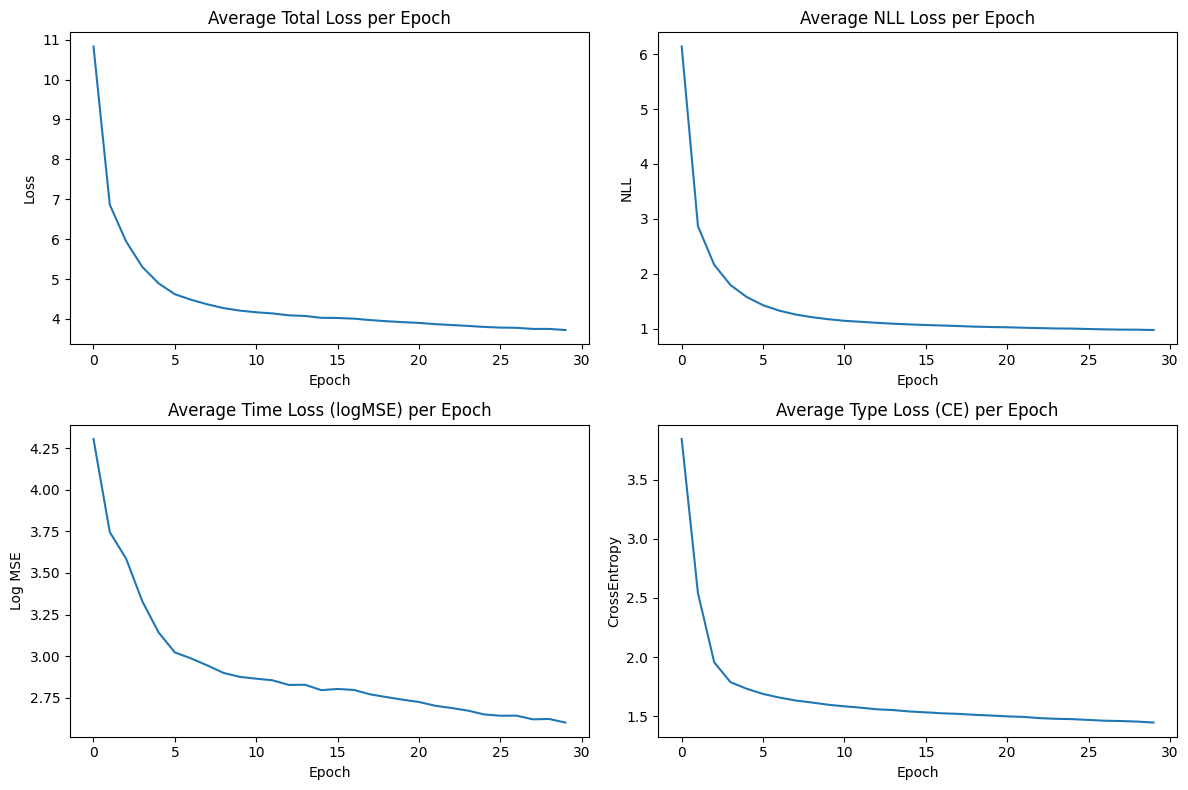

In [28]:
# @title 10-1. Data: SO (StackOverflow) folder1
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_so/fold1/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold2/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 4777
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold2/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 530
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold2/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 1326

Number of event types (K): 22
Model 'num_event_types' (K+1 for padding): 23
Actual number

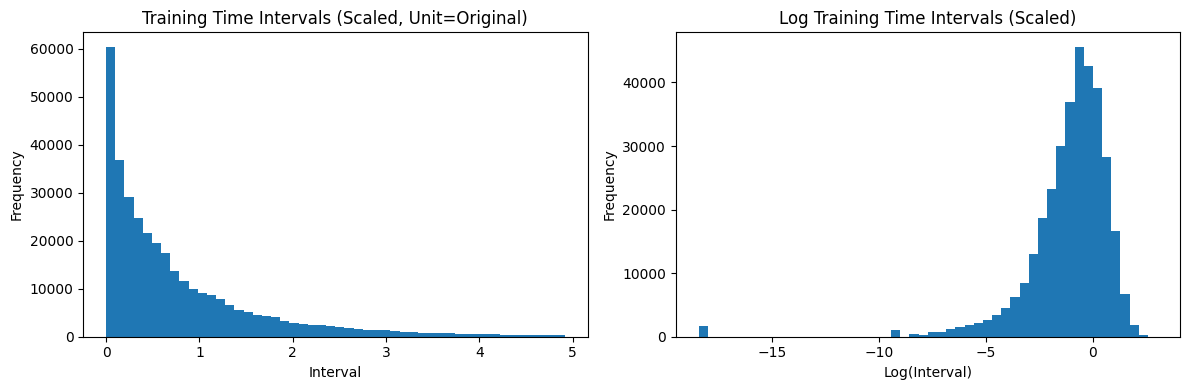

Interval Stats (Scaled): Mean=0.83, Median=0.48, Max=20.34, Min=0.00, 99th Percentile=4.91

Model created with 71004 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/30 | Time: 2.37s | Avg Loss: 11.1457 | Avg NLL: 6.2120 | Avg Time(logMSE): 4.5828 | Avg Type(CE): 3.5091


Epoch 2/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/30 | Time: 2.39s | Avg Loss: 6.9054 | Avg NLL: 2.8315 | Avg Time(logMSE): 3.8289 | Avg Type(CE): 2.4501


...

Epoch 30/30 | Time: 2.44s | Avg Loss: 3.6275 | Avg NLL: 0.9731 | Avg Time(logMSE): 2.5073 | Avg Type(CE): 1.4706
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/17 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 35239
Total Valid Predictions: 32655
Average NLL per event: 0.9671
Time Prediction RMSE: 1.0434
Type Prediction Accuracy: 51.21%
Type Prediction CrossEntropy: 1.4615

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/42 [00:00<?, ?it/s]


--- Evaluation Results (Test Set) ---
Total Valid Events: 91484
Total Valid Predictions: 84608
Average NLL per event: 0.9317
Time Prediction RMSE: 0.9962
Type Prediction Accuracy: 51.14%
Type Prediction CrossEntropy: 1.4657


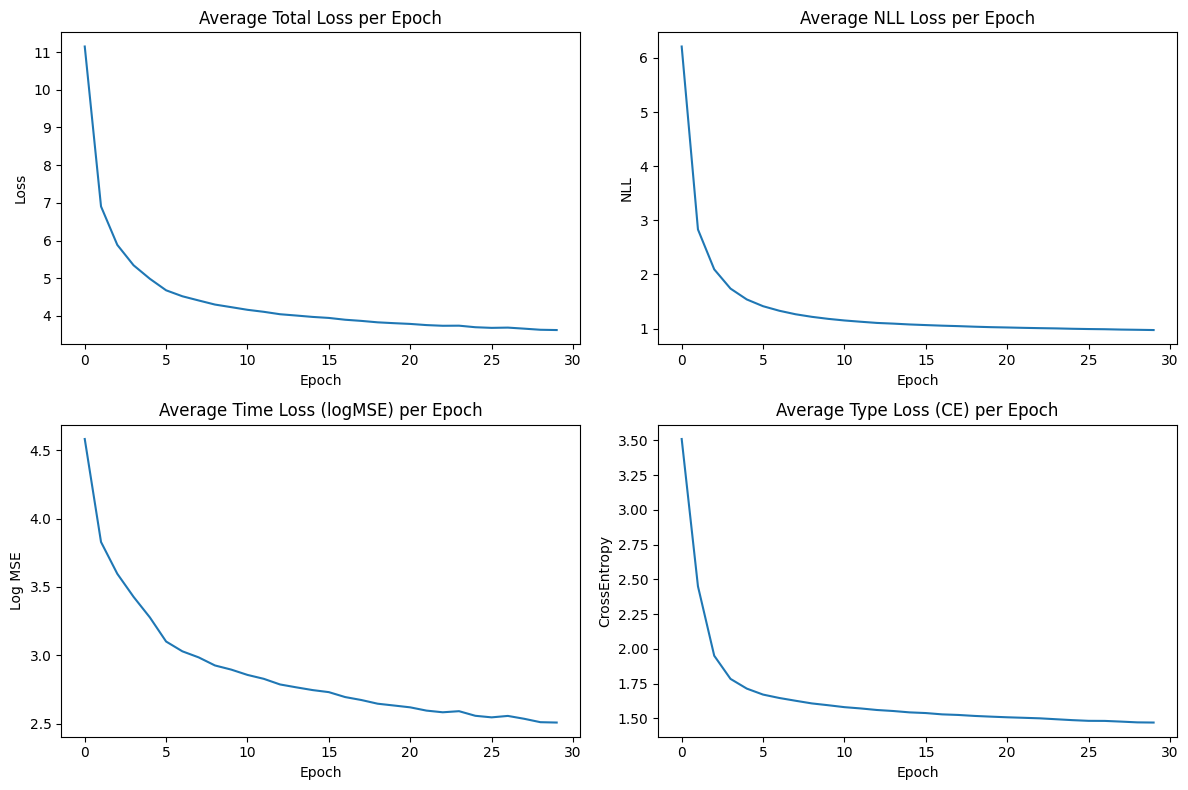

In [29]:
# @title 10-2. Data: SO folder2
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_so/fold2/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold3/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 4777
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold3/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 530
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold3/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 1326

Number of event types (K): 22
Model 'num_event_types' (K+1 for padding): 23
Actual number

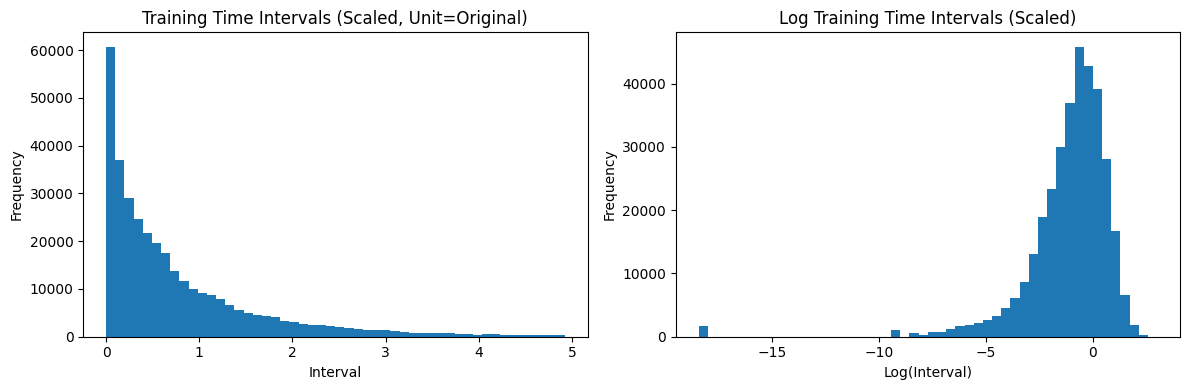

Interval Stats (Scaled): Mean=0.83, Median=0.48, Max=20.34, Min=0.00, 99th Percentile=4.92

Model created with 71004 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/30 | Time: 2.37s | Avg Loss: 11.0626 | Avg NLL: 6.0121 | Avg Time(logMSE): 4.7399 | Avg Type(CE): 3.1063


Epoch 2/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/30 | Time: 2.30s | Avg Loss: 7.0318 | Avg NLL: 2.9255 | Avg Time(logMSE): 3.8842 | Avg Type(CE): 2.2208


...

Epoch 30/30 | Time: 2.35s | Avg Loss: 3.6902 | Avg NLL: 0.9786 | Avg Time(logMSE): 2.5625 | Avg Type(CE): 1.4910
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/17 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 35750
Total Valid Predictions: 32962
Average NLL per event: 0.9674
Time Prediction RMSE: 1.0583
Type Prediction Accuracy: 50.70%
Type Prediction CrossEntropy: 1.4792

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/42 [00:00<?, ?it/s]


--- Evaluation Results (Test Set) ---
Total Valid Events: 90394
Total Valid Predictions: 83740
Average NLL per event: 0.9505
Time Prediction RMSE: 1.0475
Type Prediction Accuracy: 51.71%
Type Prediction CrossEntropy: 1.4398


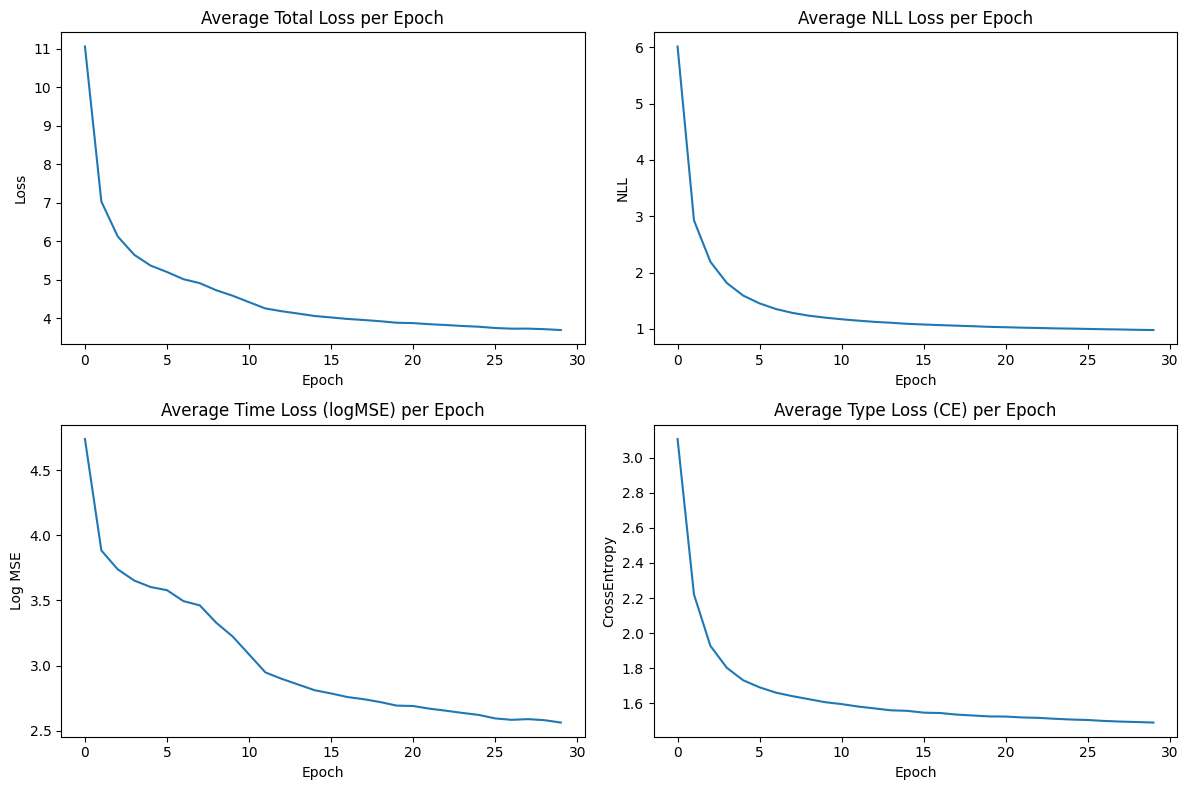

In [30]:
# @title 10-3. Data: SO folder3
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_so/fold3/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold4/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 4777
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold4/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 530
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold4/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 1326

Number of event types (K): 22
Model 'num_event_types' (K+1 for padding): 23
Actual number

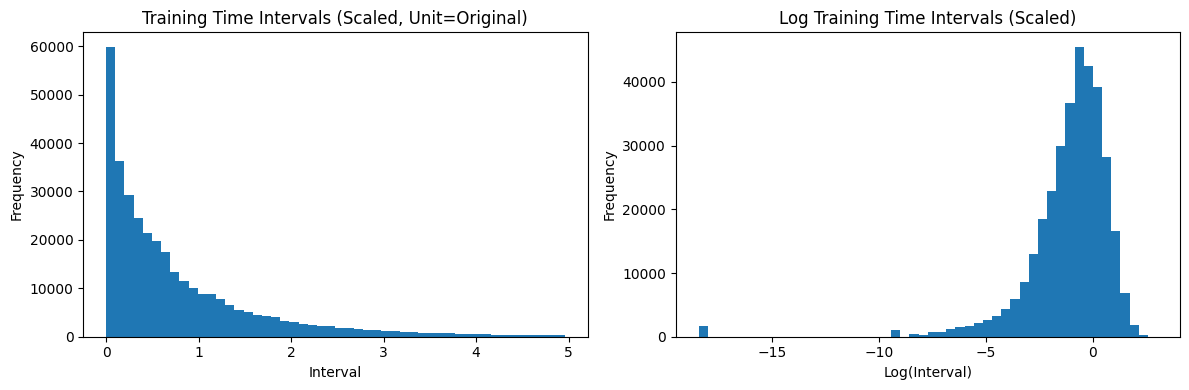

Interval Stats (Scaled): Mean=0.83, Median=0.48, Max=20.34, Min=0.00, 99th Percentile=4.96

Model created with 71004 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/30 | Time: 2.34s | Avg Loss: 10.3750 | Avg NLL: 5.4964 | Avg Time(logMSE): 4.5946 | Avg Type(CE): 2.8399


Epoch 2/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/30 | Time: 2.35s | Avg Loss: 6.7960 | Avg NLL: 2.7237 | Avg Time(logMSE): 3.8448 | Avg Type(CE): 2.2752


...

Epoch 30/30 | Time: 2.34s | Avg Loss: 3.6728 | Avg NLL: 0.9829 | Avg Time(logMSE): 2.5398 | Avg Type(CE): 1.5010
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/17 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 37889
Total Valid Predictions: 35041
Average NLL per event: 0.9241
Time Prediction RMSE: 0.9951
Type Prediction Accuracy: 49.62%
Type Prediction CrossEntropy: 1.4943

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/42 [00:00<?, ?it/s]


--- Evaluation Results (Test Set) ---
Total Valid Events: 90727
Total Valid Predictions: 84066
Average NLL per event: 0.9528
Time Prediction RMSE: 1.0462
Type Prediction Accuracy: 50.40%
Type Prediction CrossEntropy: 1.4847


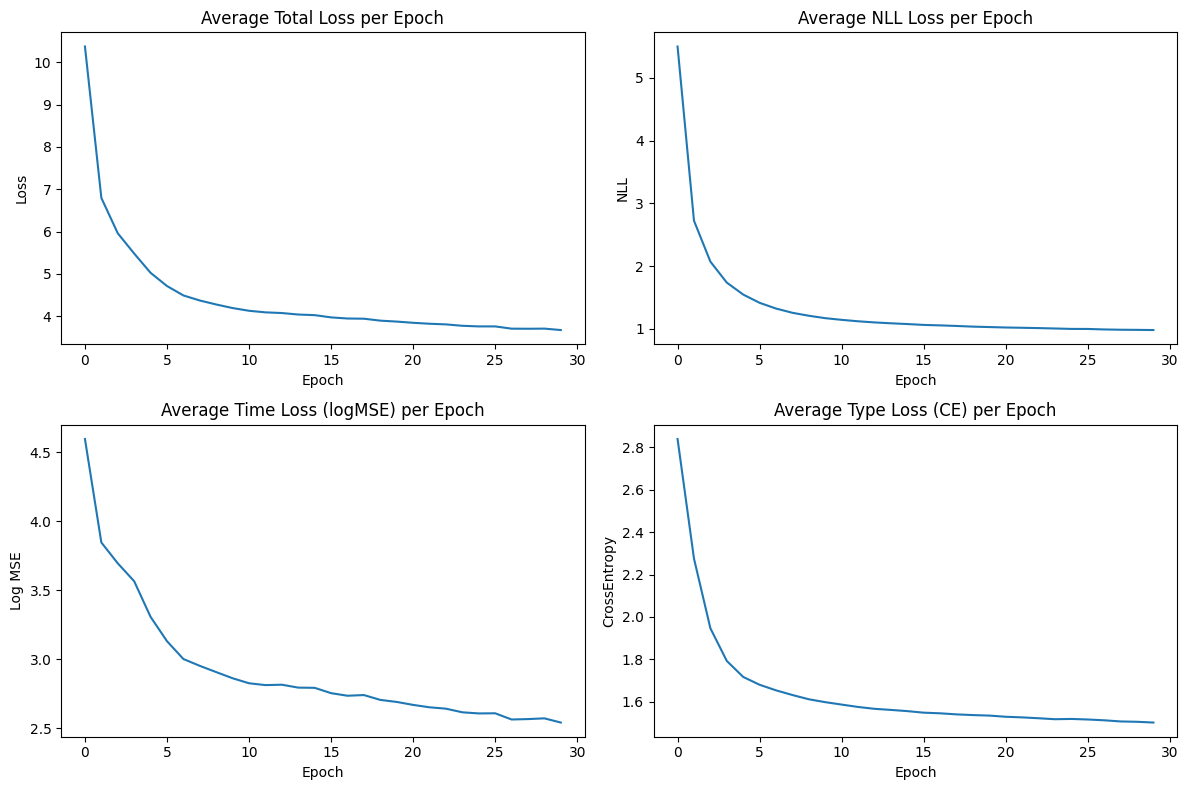

In [31]:
# @title 10-4. Data: SO folder4
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_so/fold4/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold5/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 4777
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold5/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 530
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_so/fold5/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 22
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 1326

Number of event types (K): 22
Model 'num_event_types' (K+1 for padding): 23
Actual number

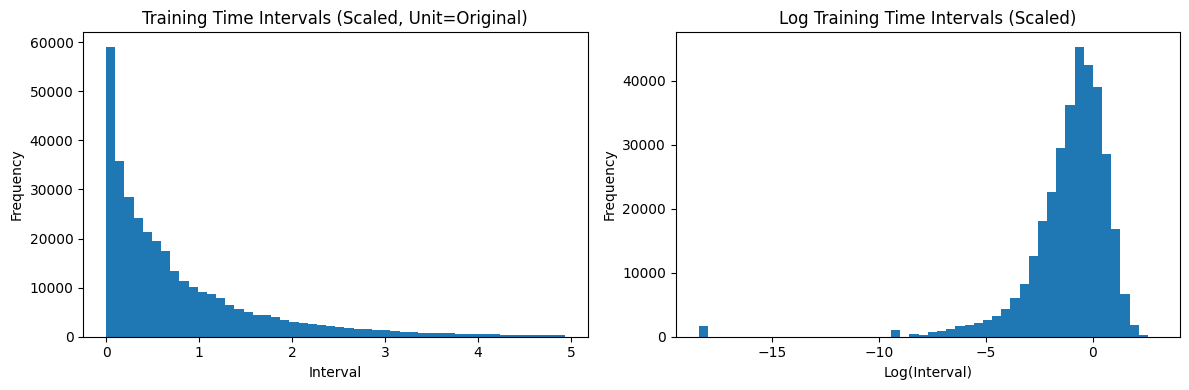

Interval Stats (Scaled): Mean=0.84, Median=0.49, Max=20.34, Min=0.00, 99th Percentile=4.93

Model created with 71004 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 1/30 | Time: 2.32s | Avg Loss: 10.4539 | Avg NLL: 5.6299 | Avg Time(logMSE): 4.3972 | Avg Type(CE): 4.2689


Epoch 2/30:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 2/30 | Time: 2.32s | Avg Loss: 6.7766 | Avg NLL: 2.6368 | Avg Time(logMSE): 3.8627 | Avg Type(CE): 2.7714


...

Epoch 30/30 | Time: 2.46s | Avg Loss: 3.6624 | Avg NLL: 0.9836 | Avg Time(logMSE): 2.5319 | Avg Type(CE): 1.4686
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/17 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 38980
Total Valid Predictions: 35974
Average NLL per event: 0.9119
Time Prediction RMSE: 0.9670
Type Prediction Accuracy: 50.83%
Type Prediction CrossEntropy: 1.4268

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/42 [00:00<?, ?it/s]


--- Evaluation Results (Test Set) ---
Total Valid Events: 91383
Total Valid Predictions: 84573
Average NLL per event: 0.9394
Time Prediction RMSE: 1.0336
Type Prediction Accuracy: 50.67%
Type Prediction CrossEntropy: 1.4367


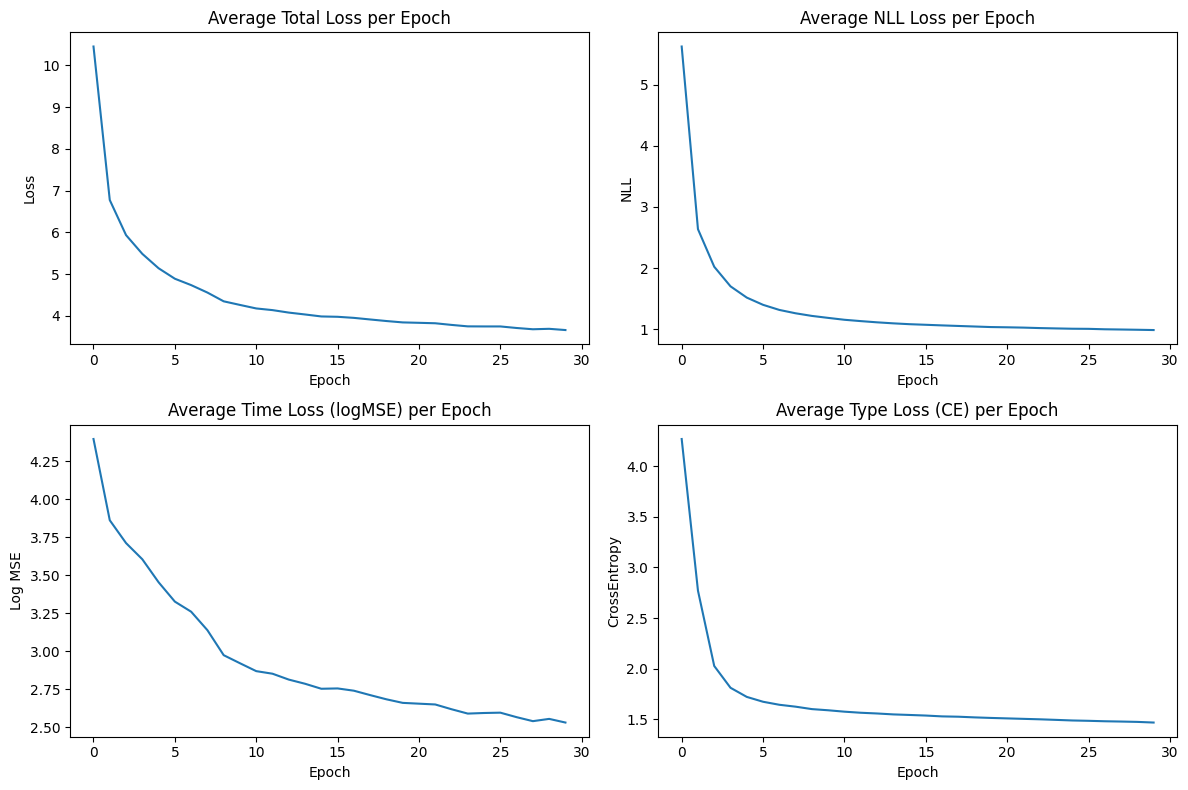

In [32]:
# @title 10-5. Data: SO folder5
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_so/fold5/"
get_result(data_path)

In [25]:
# @title 11-0. Configuration / Hyperparameters


# Model Parameters (Adjust based on StackOverflow in paper/reference code if possible)
d_model = 128       # Model dimension
n_head = 8         # Number of attention heads
d_k = d_model // n_head # Dimension of key/query per head
d_v = d_model // n_head # Dimension of value per head
d_inner = 256      # Dimension of inner layer in feed-forward net
n_layers = 4       # Number of Transformer layers
dropout = 0.1      # Dropout rate

# Point Process Parameters - Will be set from data
num_event_types = None # Set later from pkl['dim_process'] + 1 (for padding)

# Training Parameters
epochs = 30 # Increased epochs might be needed
batch_size = 16
# >>>>> Critical: Adjust Learning Rate and Weights based on experiments <<<<<
learning_rate = 1e-4 # Start potentially lower, especially if loss doesn't decrease
log_likelihood_weight = 1.0
prediction_time_weight = 1.0 # Increased weight for time prediction
prediction_type_weight = 1.5 # Potentially decrease type weight if accuracy is already high

# Small constant for numerical stability (e.g., log(x+eps))
EPS = 1e-8

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold1/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 527
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold1/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 58
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold1/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 65

Number of event types (K): 75
Model 'num_event_types' (K+1 for padding): 76
Actual n

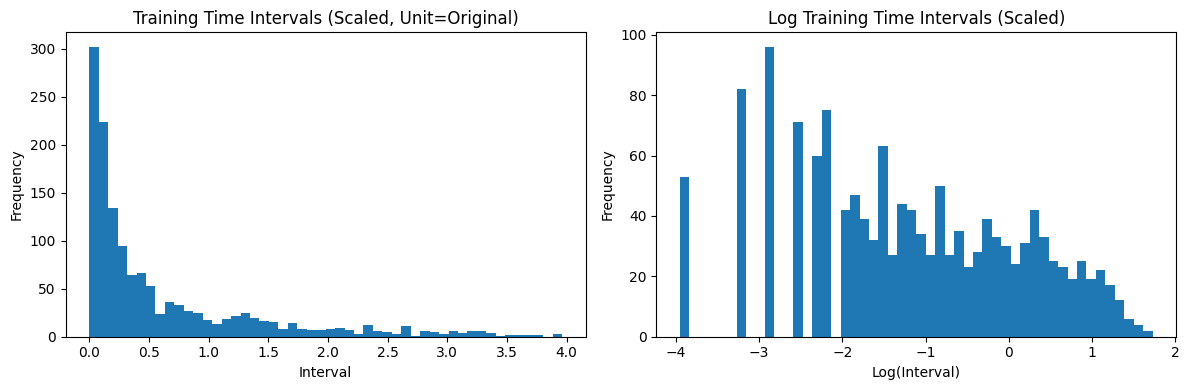

Interval Stats (Scaled): Mean=0.66, Median=0.27, Max=5.62, Min=0.02, 99th Percentile=3.96

Model created with 557488 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/30 | Time: 0.58s | Avg Loss: 17.9582 | Avg NLL: 10.0697 | Avg Time(logMSE): 2.3201 | Avg Type(CE): 3.7122


Epoch 2/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/30 | Time: 0.57s | Avg Loss: 12.2596 | Avg NLL: 7.1565 | Avg Time(logMSE): 1.8804 | Avg Type(CE): 2.1485


...

Epoch 30/30 | Time: 0.57s | Avg Loss: 1.6814 | Avg NLL: 0.6379 | Avg Time(logMSE): 0.7220 | Avg Type(CE): 0.2143
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/4 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 136
Total Valid Predictions: 93
Average NLL per event: 0.7653
Time Prediction RMSE: 0.6173
Type Prediction Accuracy: 89.25%
Type Prediction CrossEntropy: 0.6387

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/5 [00:00<?, ?it/s]

Visualizing attention for sequence 0 (actual length: 4)


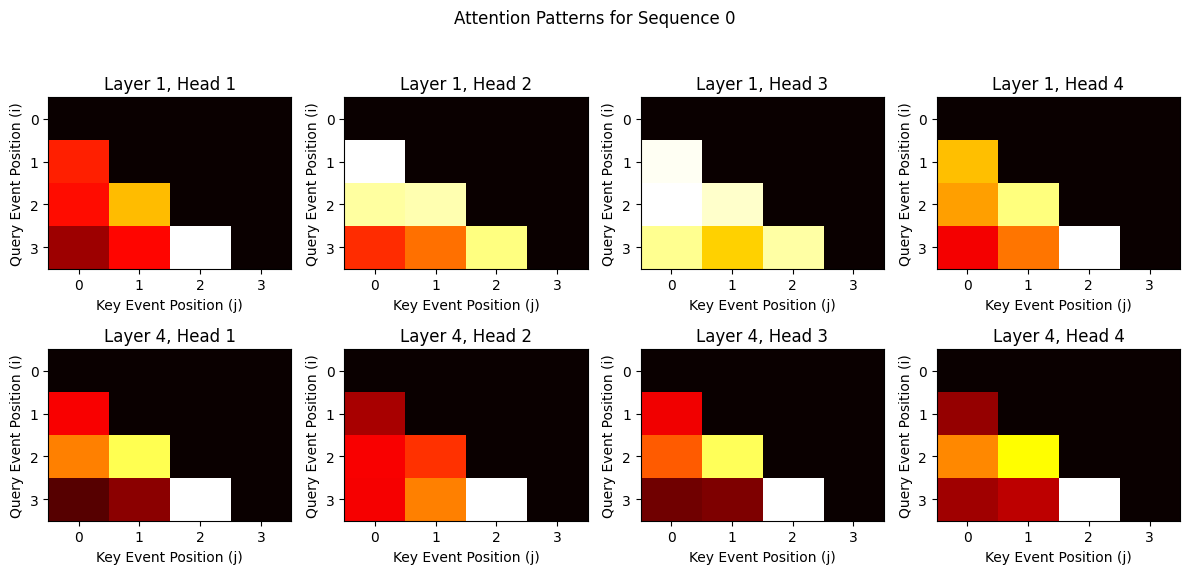


--- Evaluation Results (Test Set) ---
Total Valid Events: 145
Total Valid Predictions: 105
Average NLL per event: 0.7871
Time Prediction RMSE: 0.3508
Type Prediction Accuracy: 81.90%
Type Prediction CrossEntropy: 1.0220


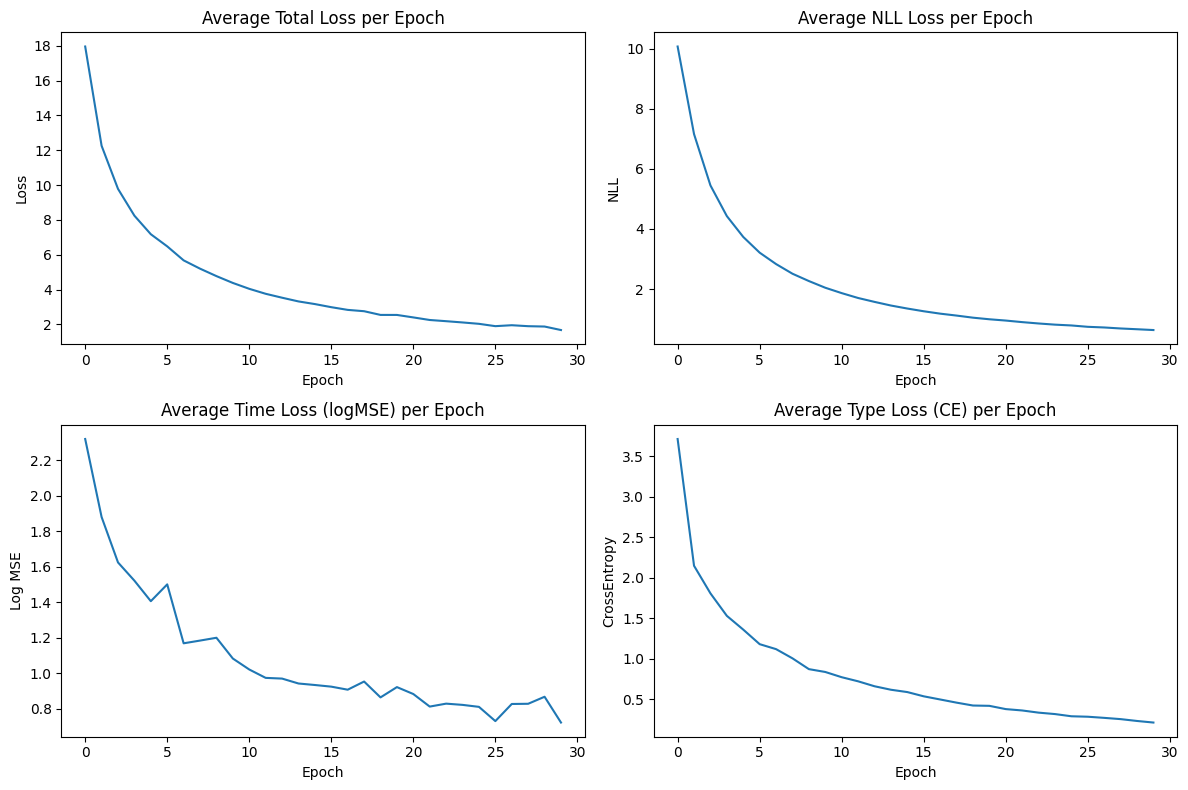

In [26]:
# @title 11-1. Data: MIMIC-II folder1
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold1/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold2/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 527
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold2/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 58
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold2/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 65

Number of event types (K): 75
Model 'num_event_types' (K+1 for padding): 76
Actual n

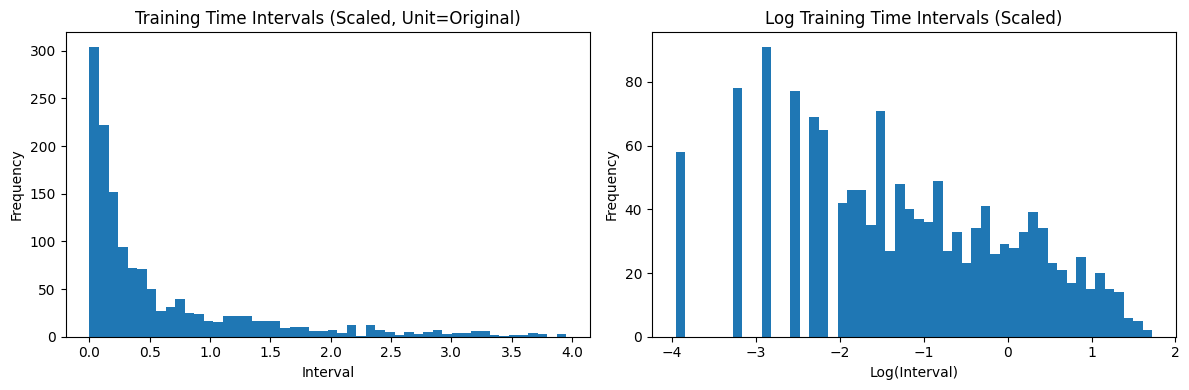

Interval Stats (Scaled): Mean=0.64, Median=0.27, Max=5.62, Min=0.02, 99th Percentile=3.95

Model created with 557488 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/30 | Time: 0.59s | Avg Loss: 19.2383 | Avg NLL: 10.7594 | Avg Time(logMSE): 2.9693 | Avg Type(CE): 3.6731


Epoch 2/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/30 | Time: 0.59s | Avg Loss: 13.0311 | Avg NLL: 7.5821 | Avg Time(logMSE): 2.0184 | Avg Type(CE): 2.2871


...

Epoch 30/30 | Time: 0.58s | Avg Loss: 1.8654 | Avg NLL: 0.6854 | Avg Time(logMSE): 0.7972 | Avg Type(CE): 0.2552
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/4 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 125
Total Valid Predictions: 84
Average NLL per event: 0.9403
Time Prediction RMSE: 0.5475
Type Prediction Accuracy: 88.10%
Type Prediction CrossEntropy: 0.8167

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/5 [00:00<?, ?it/s]

Selected sequence 0 is empty or only padding.

--- Evaluation Results (Test Set) ---
Total Valid Events: 182
Total Valid Predictions: 138
Average NLL per event: 0.6236
Time Prediction RMSE: 0.4767
Type Prediction Accuracy: 92.03%
Type Prediction CrossEntropy: 0.5819


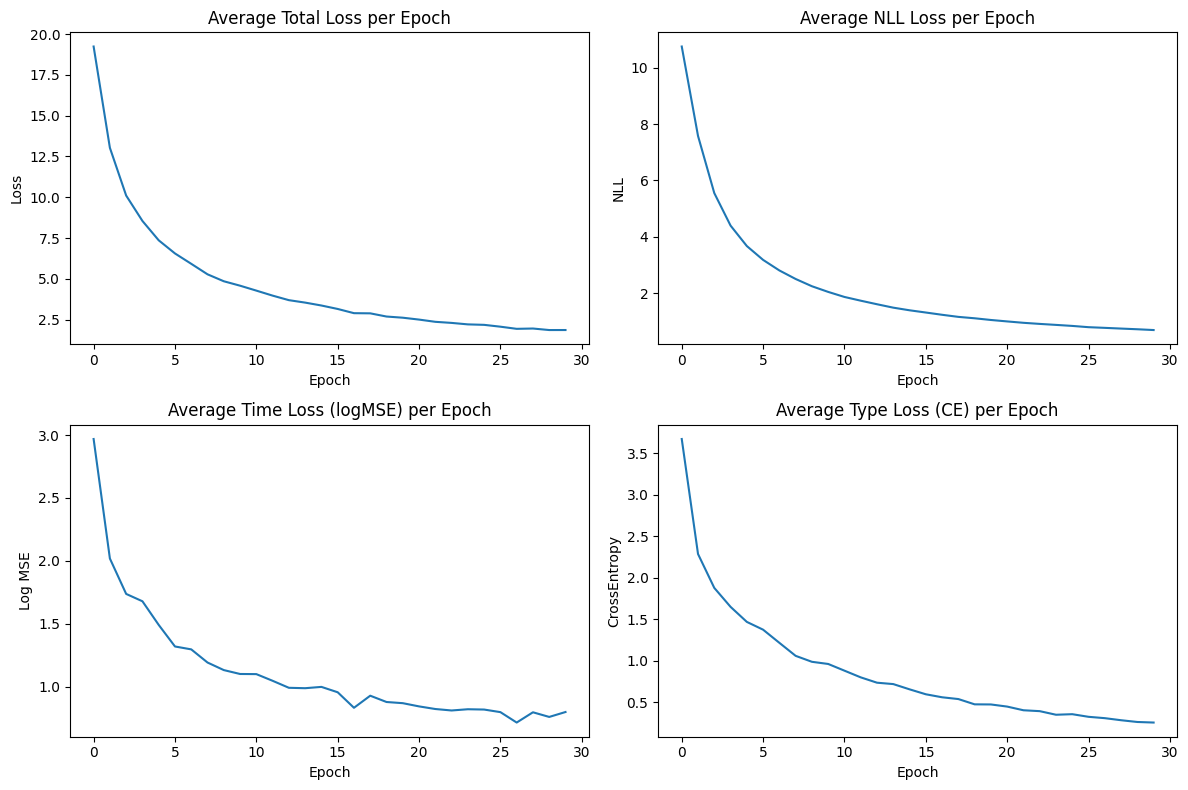

In [27]:
# @title 11-2. Data: MIMIC-II folder2
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold2/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold3/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 527
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold3/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 58
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold3/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 65

Number of event types (K): 75
Model 'num_event_types' (K+1 for padding): 76
Actual n

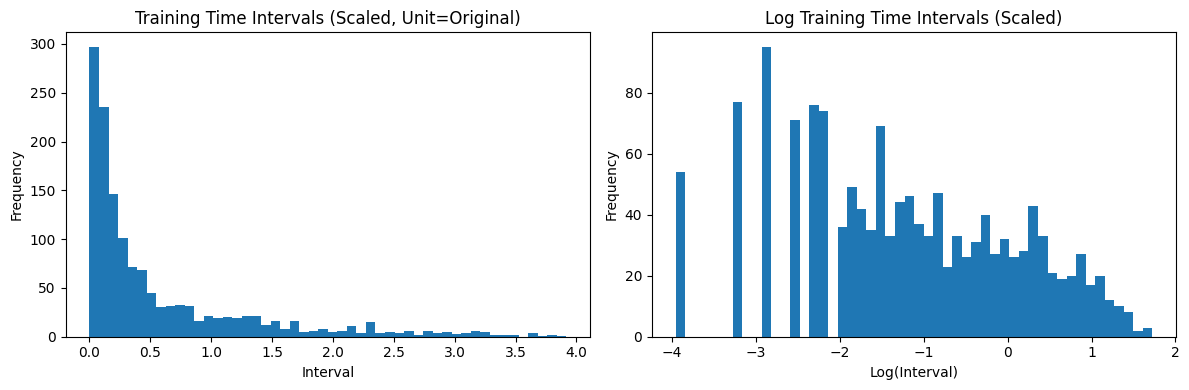

Interval Stats (Scaled): Mean=0.63, Median=0.25, Max=5.62, Min=0.02, 99th Percentile=3.92

Model created with 557488 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/30 | Time: 0.58s | Avg Loss: 17.4069 | Avg NLL: 10.2173 | Avg Time(logMSE): 2.5121 | Avg Type(CE): 3.1183


Epoch 2/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/30 | Time: 0.57s | Avg Loss: 12.0765 | Avg NLL: 7.0602 | Avg Time(logMSE): 1.8968 | Avg Type(CE): 2.0797


...

Epoch 30/30 | Time: 0.57s | Avg Loss: 1.7298 | Avg NLL: 0.6359 | Avg Time(logMSE): 0.7248 | Avg Type(CE): 0.2461
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/4 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 128
Total Valid Predictions: 88
Average NLL per event: 0.7955
Time Prediction RMSE: 0.5458
Type Prediction Accuracy: 89.77%
Type Prediction CrossEntropy: 0.7340

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/5 [00:00<?, ?it/s]

Visualizing attention for sequence 0 (actual length: 3)


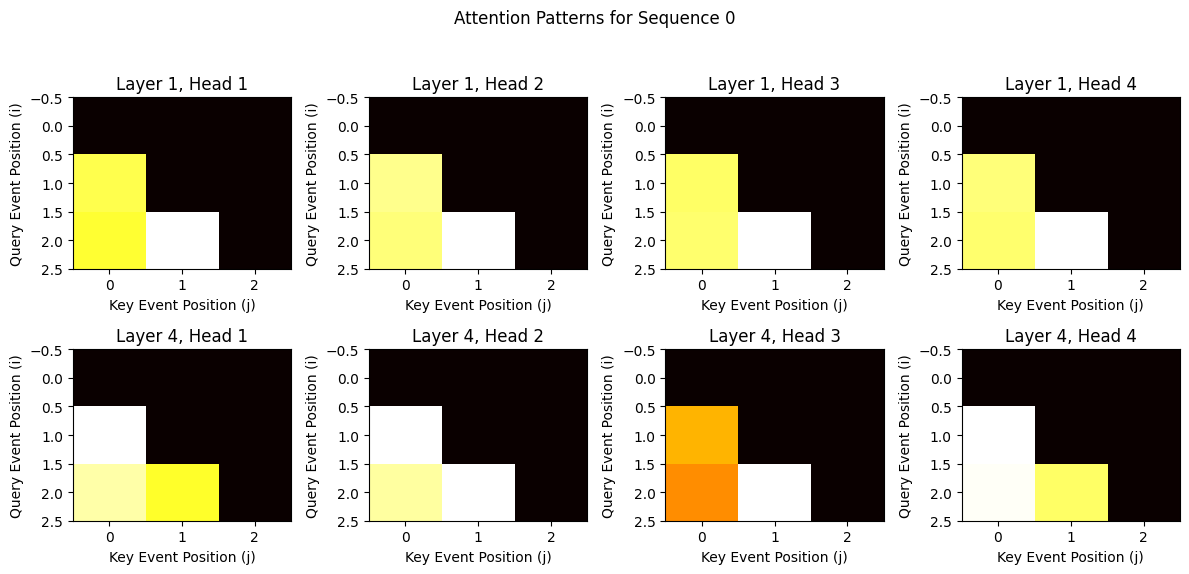


--- Evaluation Results (Test Set) ---
Total Valid Events: 176
Total Valid Predictions: 131
Average NLL per event: 1.2031
Time Prediction RMSE: 0.5609
Type Prediction Accuracy: 78.63%
Type Prediction CrossEntropy: 1.1821


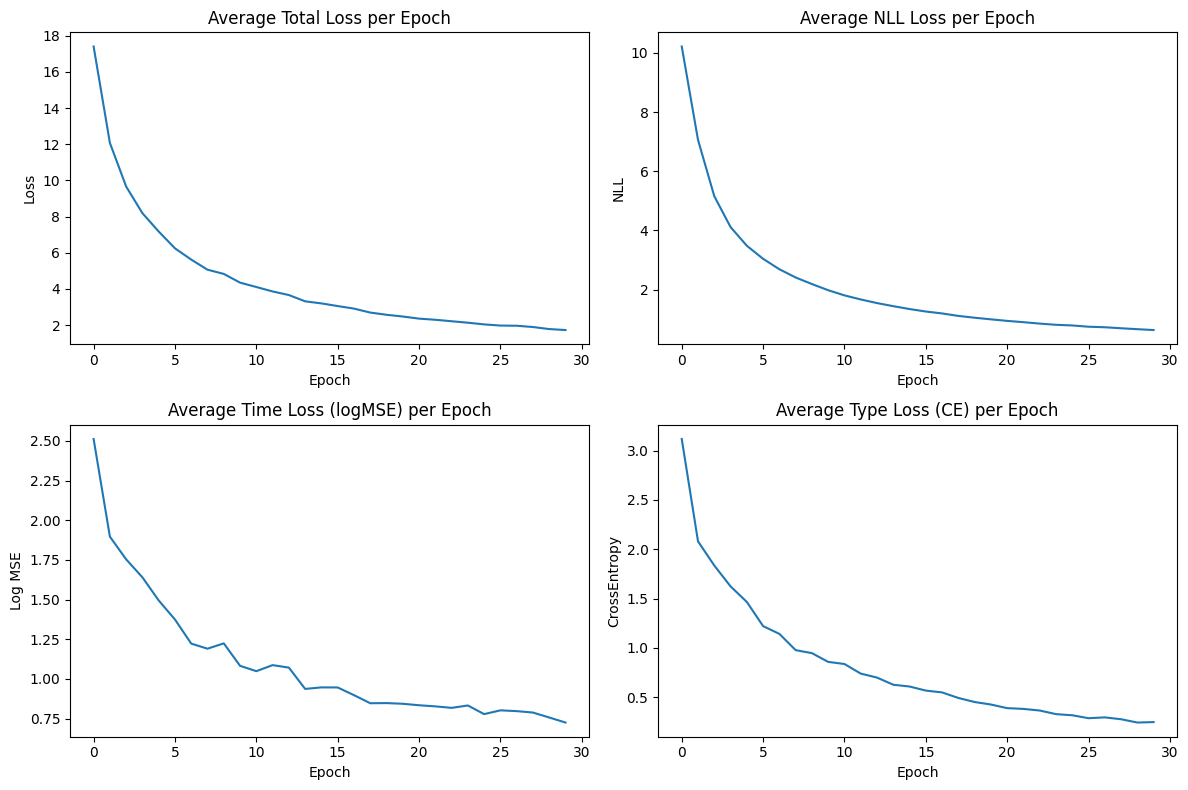

In [28]:
# @title 11-3. Data: MIMIC-II folder3
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold3/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold4/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 527
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold4/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 58
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold4/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 65

Number of event types (K): 75
Model 'num_event_types' (K+1 for padding): 76
Actual n

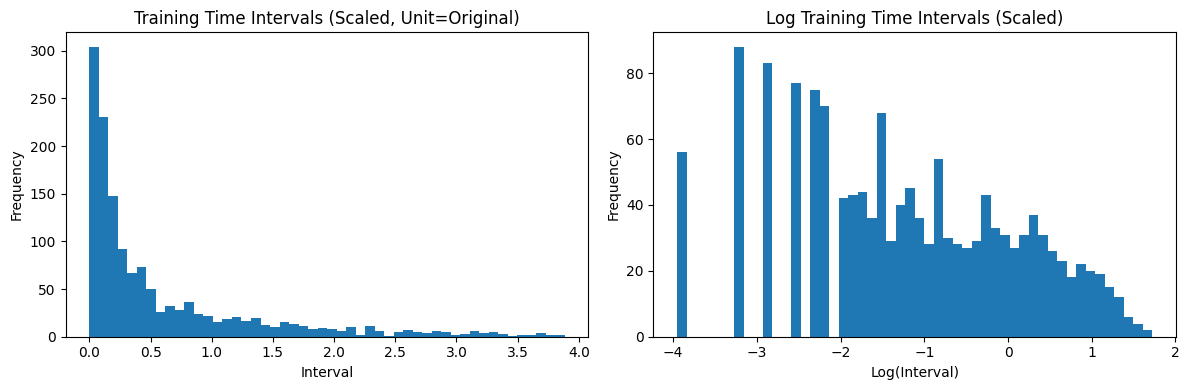

Interval Stats (Scaled): Mean=0.64, Median=0.27, Max=5.62, Min=0.02, 99th Percentile=3.88

Model created with 557488 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/30 | Time: 0.57s | Avg Loss: 19.0293 | Avg NLL: 10.2494 | Avg Time(logMSE): 2.3418 | Avg Type(CE): 4.2921


Epoch 2/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/30 | Time: 0.56s | Avg Loss: 12.5952 | Avg NLL: 7.1624 | Avg Time(logMSE): 1.8433 | Avg Type(CE): 2.3930


...

Epoch 30/30 | Time: 0.57s | Avg Loss: 1.8440 | Avg NLL: 0.6496 | Avg Time(logMSE): 0.8087 | Avg Type(CE): 0.2572
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/4 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 130
Total Valid Predictions: 87
Average NLL per event: 0.9921
Time Prediction RMSE: 0.5889
Type Prediction Accuracy: 85.06%
Type Prediction CrossEntropy: 0.9041

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/5 [00:00<?, ?it/s]

Visualizing attention for sequence 0 (actual length: 4)


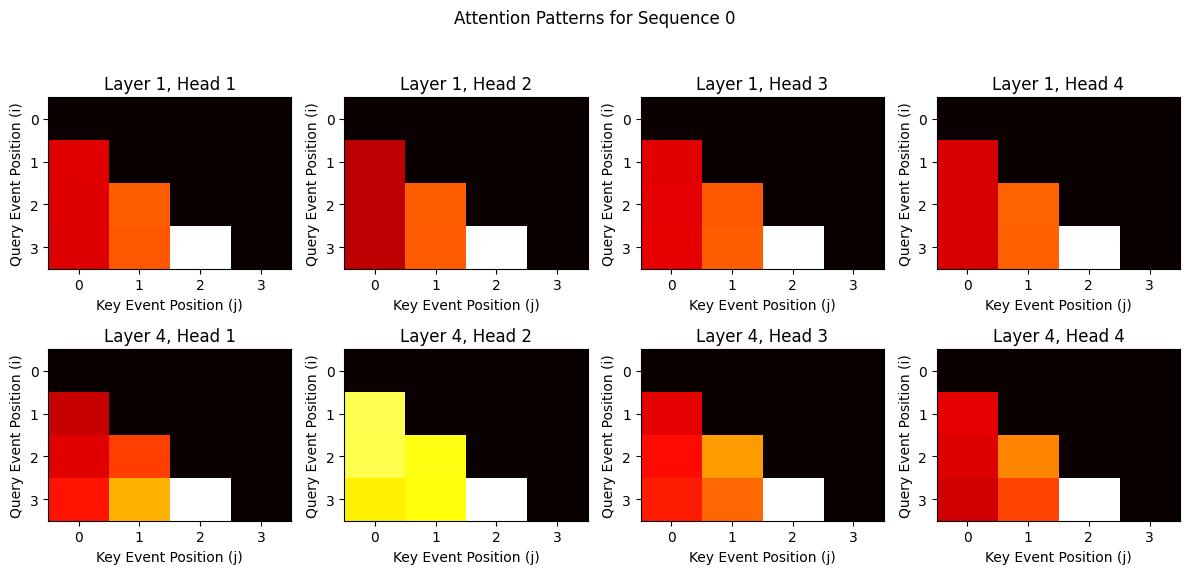


--- Evaluation Results (Test Set) ---
Total Valid Events: 173
Total Valid Predictions: 124
Average NLL per event: 1.0980
Time Prediction RMSE: 0.6838
Type Prediction Accuracy: 78.23%
Type Prediction CrossEntropy: 1.2238


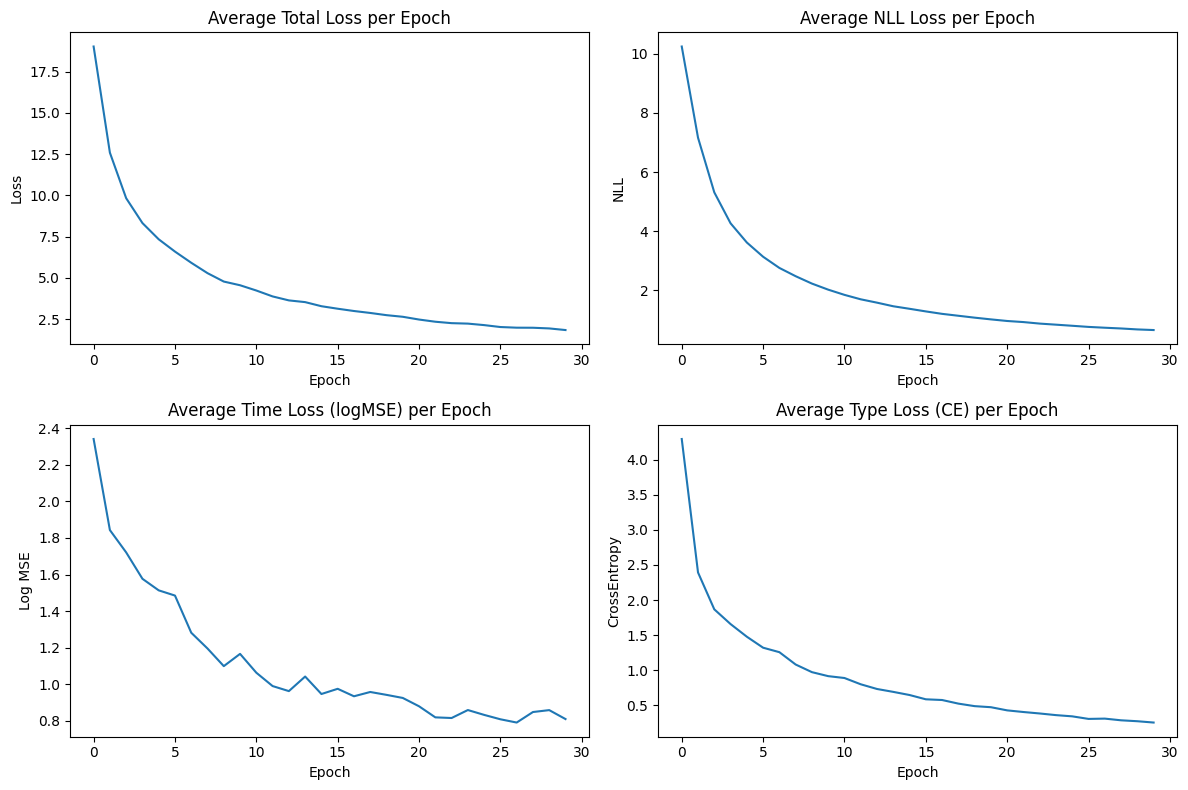

In [29]:
# @title 11-4. Data: MIMIC-II folder4
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold4/"
get_result(data_path)

Loading data from .pkl files...
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold5/train.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 527
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold5/dev.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 58
  Number of sequences in 'test': 0
Successfully loaded data from: /content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold5/test.pkl
  Keys: ['dim_process', 'devtest', 'args', 'dev', 'train', 'test']
  Dimension (K): 75
  Number of sequences in 'train': 0
  Number of sequences in 'dev': 0
  Number of sequences in 'test': 65

Number of event types (K): 75
Model 'num_event_types' (K+1 for padding): 76
Actual n

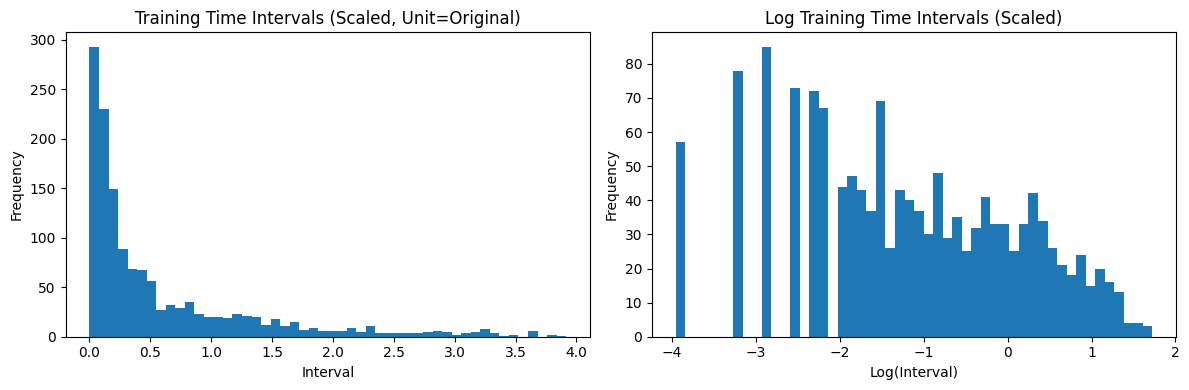

Interval Stats (Scaled): Mean=0.65, Median=0.27, Max=5.62, Min=0.02, 99th Percentile=3.92

Model created with 557488 trainable parameters.
Starting training...


Epoch 1/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 1/30 | Time: 0.60s | Avg Loss: 19.4469 | Avg NLL: 10.4933 | Avg Time(logMSE): 3.2782 | Avg Type(CE): 3.7836


Epoch 2/30:   0%|          | 0/33 [00:00<?, ?it/s]

Epoch 2/30 | Time: 0.61s | Avg Loss: 12.7551 | Avg NLL: 7.1252 | Avg Time(logMSE): 2.0847 | Avg Type(CE): 2.3634


...

Epoch 30/30 | Time: 0.58s | Avg Loss: 1.9493 | Avg NLL: 0.7508 | Avg Time(logMSE): 0.8210 | Avg Type(CE): 0.2517
Training finished.

--- Starting Evaluation on Development Set ---


Evaluating Development:   0%|          | 0/4 [00:00<?, ?it/s]


--- Evaluation Results (Development Set) ---
Total Valid Events: 116
Total Valid Predictions: 89
Average NLL per event: 0.5007
Time Prediction RMSE: 0.6022
Type Prediction Accuracy: 80.90%
Type Prediction CrossEntropy: 0.8400

--- Starting Evaluation on Test Set ---


Evaluating Test:   0%|          | 0/5 [00:00<?, ?it/s]

Visualizing attention for sequence 0 (actual length: 3)


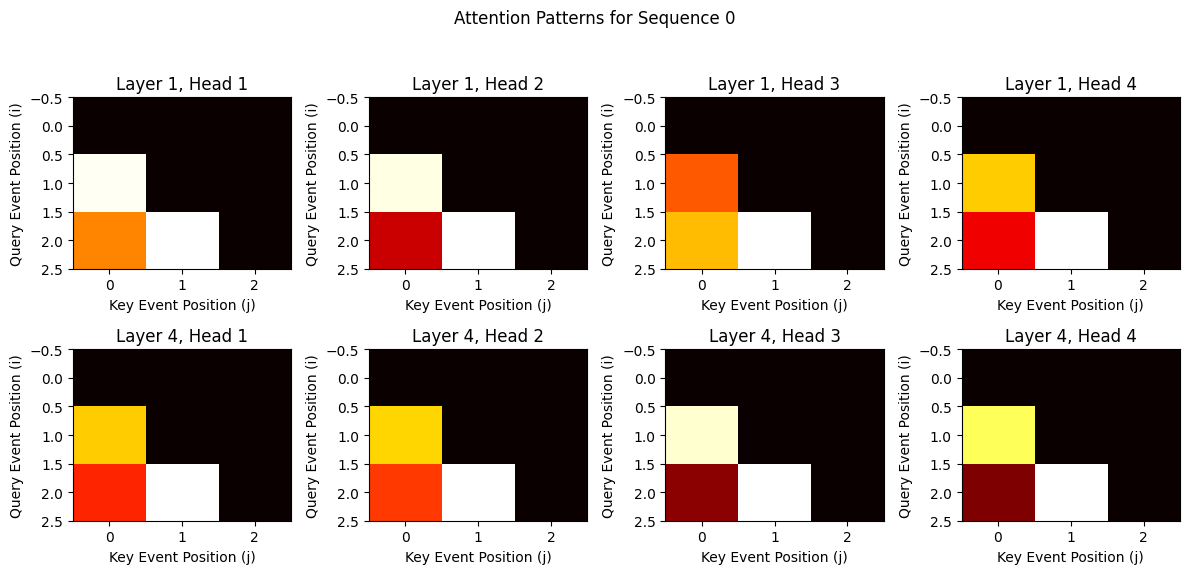


--- Evaluation Results (Test Set) ---
Total Valid Events: 174
Total Valid Predictions: 128
Average NLL per event: 0.4493
Time Prediction RMSE: 0.4700
Type Prediction Accuracy: 89.84%
Type Prediction CrossEntropy: 0.6482


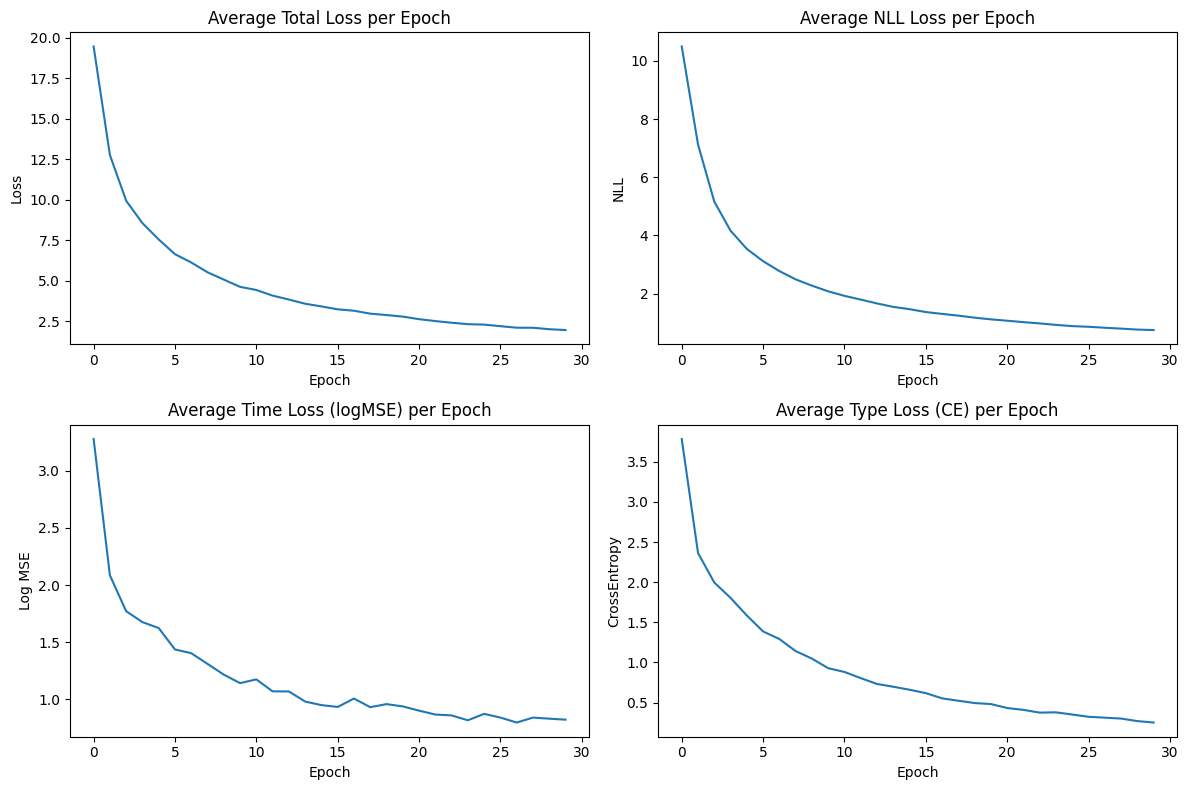

In [30]:
# @title 11-5. Data: MIMIC-II folder5
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_mimic/fold5/"
get_result(data_path)

In [10]:
# @title 12-0. Configuration / Hyperparameters


# Model Parameters (Adjust based on StackOverflow in paper/reference code if possible)
d_model = 256       # Model dimension
n_head = 16         # Number of attention heads
d_k = d_model // n_head # Dimension of key/query per head
d_v = d_model // n_head # Dimension of value per head
d_inner = 512      # Dimension of inner layer in feed-forward net
n_layers = 6       # Number of Transformer layers
dropout = 0.1      # Dropout rate

# Point Process Parameters - Will be set from data
num_event_types = None # Set later from pkl['dim_process'] + 1 (for padding)

# Training Parameters
epochs = 30 # Increased epochs might be needed
batch_size = 32
# >>>>> Critical: Adjust Learning Rate and Weights based on experiments <<<<<
learning_rate = 1e-4 # Start potentially lower, especially if loss doesn't decrease
log_likelihood_weight = 1.0
prediction_time_weight = 1.5 # Increased weight for time prediction
prediction_type_weight = 1.5 # Potentially decrease type weight if accuracy is already high

# Small constant for numerical stability (e.g., log(x+eps))
EPS = 1e-8

In [ ]:
# @title 12-1. Data: MemeTrack
data_path = "/content/drive/MyDrive/Purdue/Colab/Project/data_meme/"
get_result(data_path)